**Function 7- Bayesian Optimisation**

# Function 7 Description

You’re tasked with optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function.

Because this is a commonly used model, you might benefit from researching best practices or literature to guide your initial search space. Your goal is to find the combination of hyperparameters that yields the highest possible performance.

# Starting point

* Input - 6D array (30,6)
* Output - 1D array (30,)
* Optimisation goal - Maximise

# Bayesian Optimisation (BO) workflow on capstone project
* BO with Upper Control Bound (UCB)
* Visuals of progress and surrogate intuition
* Final training with the optimized hyperparameters

### Import Libraries

In [1]:
import io, math, pathlib, numpy as np, pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from scipy.stats import norm

import warnings
warnings.filterwarnings("ignore")

#### Setup Parameters

In [2]:
plt.rcParams['figure.figsize'] = (5,3)
plt.rcParams['figure.dpi'] = 140
plt.rcParams['axes.grid'] = True

### Assign Data to variables X and y

In [3]:
import numpy as np, pandas as pd, pathlib

# To load a .npy file into a pandas DataFrame:
# 1. Load the .npy file using numpy.load()
# 2. Convert the resulting numpy array to a pandas DataFrame using pd.DataFrame()

# Attempting to load from '/content/data/' as is common in Colab, or from a 'data/' subfolder
try:
    # Try loading from /content/data/
    X_array = np.load('/content/data/initial_inputs7.npy')
    y_array = np.load('/content/data/initial_outputs7.npy')
    print("Files loaded successfully from /content/data/")

except FileNotFoundError:
    try:
        # If not in /content/data/, try loading from a 'data/' subfolder in the current directory
        X_array = np.load('data/initial_inputs7.npy')
        y_array = np.load('data/initial_outputs7.npy')
        print("Files loaded successfully from data/ subfolder.")
    except FileNotFoundError:
       print("Error: One or both .npy files not found at /content/data/ or data/.")
       print("Please ensure they are in the correct path.")
       print("Current working directory files: ", list(pathlib.Path().absolute().glob('*.npy')))
       print("Files in /content/data/: ", list(pathlib.Path('/content/data/').absolute().glob('*.npy')))

       # Create dummy data if files are not found to allow notebook execution to proceed
       X_array = np.random.rand(30, 6) # 30 samples, 6 features
       y_array = np.random.rand(30,)  # 30 samples, 1 output
       print("\nUsing dummy data for X and y to continue.")

# Convert to DataFrame if needed, or use as NumPy arrays directly for your model
X_df = pd.DataFrame(X_array)
y_df = pd.DataFrame(y_array, columns=['target_output'])

print("Shape of X (NumPy array):", X_array.shape)
print("Shape of y (NumPy array):", y_array.shape)
print("\nFirst 5 rows of X (DataFrame):")
display(X_df.head())
print("\nFirst 5 rows of y (DataFrame):")
display(y_df.head())

# Assign X and y for subsequent steps (as NumPy arrays, based on original notebook context)
X = X_array
y = y_array


Files loaded successfully from /content/data/
Shape of X (NumPy array): (30, 6)
Shape of y (NumPy array): (30,)

First 5 rows of X (DataFrame):


,0,1,2,3,4,5
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429



First 5 rows of y (DataFrame):


,target_output
0,0.604433
1,0.562753
2,0.007503
3,0.061424
4,0.273047


To add new data points, you'll need to create new NumPy arrays for the input features (`new_X_points`) and target outputs (`new_y_points`). Ensure that the new points have the same number of features as your existing `X` array.

Then, use `np.vstack` to vertically stack the new `X` points onto the existing `X` array, and `np.concatenate` to combine the new `y` points with the existing `y` array.

In [4]:
import numpy as np

# Assume X and y are already defined from previous cells
# Example: X_array.shape = (10, 2), y_array.shape = (10,)

# Create new data points
# Make sure new_X_points has the same number of columns as X
# and new_y_points has compatible dimensions with y

# For X (features), assume 6 features per data point
# Let's add 6 new data points
new_X_points = np.array([
    [0.000001, 0.000001, 0.000001, 0.000001, 0.000001, 0.000001], # week 1 capstone submission - eye ball
    [0.144299, 0.101210, 0.726539, 0.380016, 0.237990, 0.247926], # week 2 capstone submission - KAPPA 50.0 for exploration
    [0.974165, 0.804506, 0.199135, 0.010458, 0.774429, 0.636327], # week 3 capstone submission - KAPPA 50.0 for exploration
    [0.981147, 0.877015, 0.205525, 0.304759, 0.558392, 0.496625], # week 4 capstone submission - KAPPA 200.0 for exploration
    [0.315886, 0.999424, 0.020606, 0.840596, 0.106560, 0.969401], # week 5 capstone submission - KAPPA 500 for exploration
    [0.766774, 0.047092, 0.354289, 0.571574, 0.291259, 0.684808], # week 6 capstone submission - KAPPA 1000 for exploration
    [0.967797, 0.654042, 0.307720, 0.842823, 0.040042, 0.982265], # week 7 capstone submission - KAPPA 5.0 for exploitation and increased n_estimators to 600.0 after reviewing last two plots
    [0.988278, 0.474088, 0.706959, 0.285924, 0.685002, 0.599561], # week 8 capstone submission - KAPPA 2.0
    [0.477967, 0.071502, 0.246622, 0.566581, 0.183852, 0.247667], # week 9 capstone submission - KAPPA 0.1 from BO
    [0.065159, 0.434516, 0.922219, 0.313490, 0.387940, 0.766274], # week 10 capstone submission -KAPPA 0.25 from BO
    [0.026298, 0.439457, 0.034568, 0.140304, 0.333971, 0.791247], # week 11 capstone submission - KAPPA 0.1 from BO, changed n_estimators lower range to 10
    [0.731439, 0.692887, 0.918563, 0.156422, 0.397594, 0.752305], # week 12 capstone submission - KAPPA 0.1 from BO
    [0.037981, 0.435318, 0.287145, 0.635668, 0.447543, 0.739160]  # week 13 capstone submission - KAPPA 0.1 from BO
])

# For y (target), assume a single output value per data point
new_y_points = np.array([
    0.005089268017732086,  # week 1 capstone processed output
    0.5707497863574206,    # week 2 capstone processed output
    0.0013483027084843504, # week 3 capstone processed output
    0.022488849763483632,  # week 4 capstone processed output
    0.002209818009268405,  # week 5 capstone processed output
    0.5556727682608081,    # week 6 capstone processed output
    0.007441793236581262,  # week 7 capstone processed output
    0.031242098022477127,  # week 8 capstone processed output
    0.22772164159445527,   # week 9 capstone processed output
    1.2439098169981415,    # week 10 capstone processed output
    1.144610310468577,     # week 11 capstone processed output
    0.2986281793616133,    # week 12 capstone processed output
    0.43693118862601354    # week 13 capstone processed output
])

# Verify shapes before adding
print(f"Original X shape: {X.shape}")
print(f"Original y shape: {y.shape}")
print(f"New X points shape: {new_X_points.shape}")
print(f"New y points shape: {new_y_points.shape}")

# Add the new data points
X = np.vstack([X, new_X_points])
y = np.concatenate([y, new_y_points])

print(f"\nUpdated X shape: {X.shape}")
print(f"Updated y shape: {y.shape}")

# Display the last few rows to see the added data
print("\nLast 5 rows of updated X:")
display(pd.DataFrame(X).tail())
print("\nLast 5 rows of updated y:")
display(pd.DataFrame(y, columns=['target_output']).tail())


Original X shape: (30, 6)
Original y shape: (30,)
New X points shape: (13, 6)
New y points shape: (13,)

Updated X shape: (43, 6)
Updated y shape: (43,)

Last 5 rows of updated X:


,0,1,2,3,4,5
38,0.477967,0.071502,0.246622,0.566581,0.183852,0.247667
39,0.065159,0.434516,0.922219,0.313490,0.387940,0.766274
40,0.026298,0.439457,0.034568,0.140304,0.333971,0.791247
41,0.731439,0.692887,0.918563,0.156422,0.397594,0.752305
42,0.037981,0.435318,0.287145,0.635668,0.447543,0.739160



Last 5 rows of updated y:


,target_output
38,0.227722
39,1.243910
40,1.144610
41,0.298628
42,0.436931


Finding the top 3 input (X) values that generated the highest output (y) values:

Top 3 Highest Output Values (y) and their corresponding X values:
   Original Index: 6
   y value: 1.3649683045e+00
   Corresponding X values: [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]


   Original Index: 39
   y value: 1.2439098170e+00
   Corresponding X values: [0.065159 0.434516 0.922219 0.31349  0.38794  0.766274]


   Original Index: 40
   y value: 1.1446103105e+00
   Corresponding X values: [0.026298 0.439457 0.034568 0.140304 0.333971 0.791247]


Finding the top 3 input (X) values that generated the lowest output (y) values:

Top 3 Lowest Output Values (y) and their corresponding X values:
   Original Index: 32
   y value: 1.3483027085e-03
   Corresponding X values: [0.974165 0.804506 0.199135 0.010458 0.774429 0.636327]


   Original Index: 34
   y value: 2.2098180093e-03
   Corresponding X values: [0.315886 0.999424 0.020606 0.840596 0.10656  0.969401]


   Original Ind

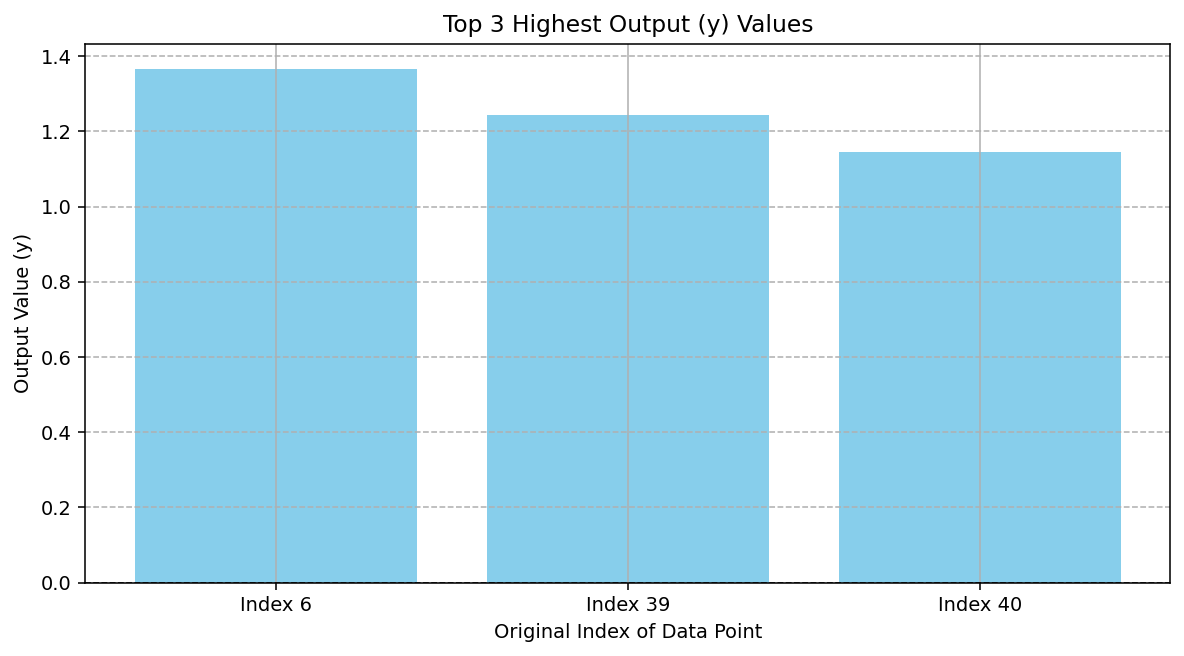

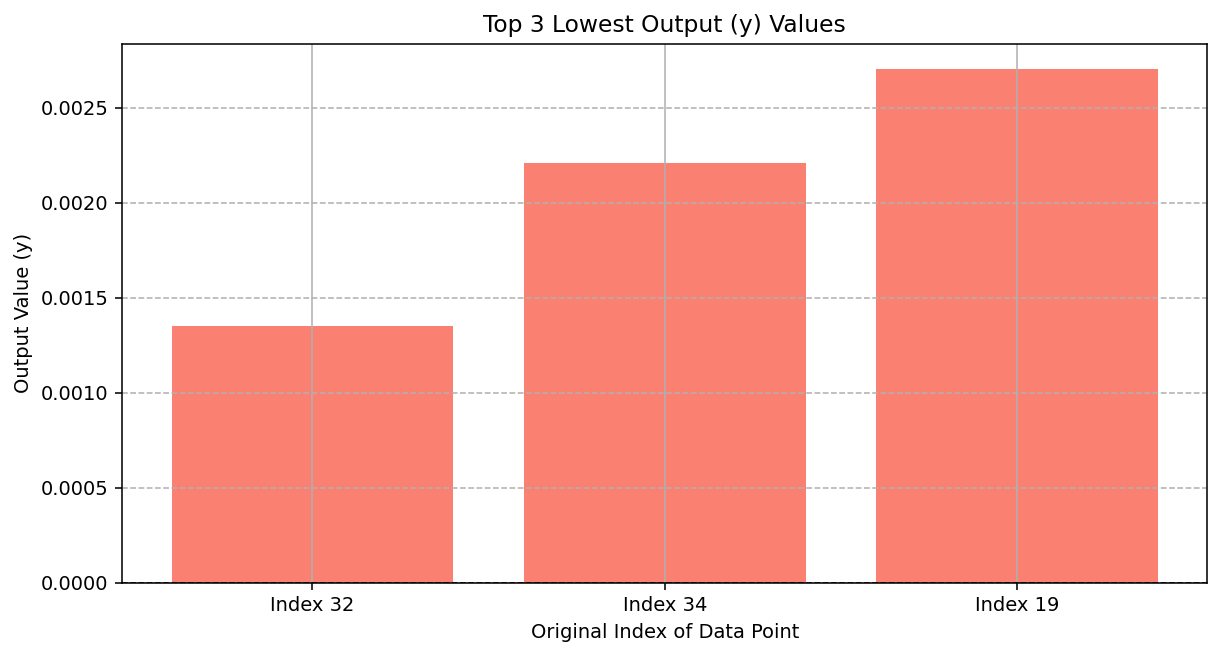

In [5]:
print("Finding the top 3 input (X) values that generated the highest output (y) values:")

# Get indices that would sort y in descending order (highest values are at the beginning)
sorted_indices_highest = np.argsort(y)[::-1]

# Select the top 3 indices for the highest y values
top_3_indices_highest = sorted_indices_highest[:3]

# Get the corresponding X and y values
top_3_X_highest = X[top_3_indices_highest]
top_3_y_highest = y[top_3_indices_highest]

print("\nTop 3 Highest Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_highest):
  print(f"   Original Index: {top_3_indices_highest[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_highest[i]}")
  print("\n")

print("Finding the top 3 input (X) values that generated the lowest output (y) values:")

# Get indices that would sort y in ascending order (lowest values are at the beginning)
sorted_indices_lowest = np.argsort(y)

# Select the top 3 indices for the lowest y values
top_3_indices_lowest = sorted_indices_lowest[:3]

# Get the corresponding X and y values
top_3_X_lowest = X[top_3_indices_lowest]
top_3_y_lowest = y[top_3_indices_lowest]

print("\nTop 3 Lowest Output Values (y) and their corresponding X values:")
for i, val_y in enumerate(top_3_y_lowest):
  print(f"   Original Index: {top_3_indices_lowest[i]}")
  print(f"   y value: {val_y:.10e}")
  print(f"   Corresponding X values: {top_3_X_lowest[i]}")
  print("\n")

  # Plotting the top 3 highest y values
plt.figure(figsize=(10, 5))
plt.bar([f'Index {idx}' for idx in top_3_indices_highest], top_3_y_highest, color='skyblue')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Added baseline at y=0
plt.xlabel('Original Index of Data Point')
plt.ylabel('Output Value (y)')
plt.title('Top 3 Highest Output (y) Values')
plt.grid(axis='y', linestyle='--')
plt.show()

# Plotting the top 3 lowest y values
plt.figure(figsize=(10, 5))
plt.bar([f'Index {idx}' for idx in top_3_indices_lowest], top_3_y_lowest, color='salmon')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8) # Added baseline at y=0
plt.xlabel('Original Index of Data Point')
plt.ylabel('Output Value (y)')
plt.title('Top 3 Lowest Output (y) Values')
plt.grid(axis='y', linestyle='--')
plt.show()


### Objective and baseline
Baseline model provides us the RMSE benchmark as a starting point

In [6]:
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import GradientBoostingRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)
def rmse_cv(model):
    scores = cross_val_score(model, X, y, cv=cv, scoring="neg_mean_squared_error")
    return float(np.sqrt(-scores).mean())

baseline = GradientBoostingRegressor(random_state=42)
baseline_rmse = rmse_cv(baseline)
print(f"Baseline GBR RMSE (5-fold): {baseline_rmse:.3f}")

Baseline GBR RMSE (5-fold): 0.458


### Search Space and Helper Functions

In [7]:
# Search space for 6D input (n_estimators, learning_rate, max_depth, subsample, min_samples_leaf, max_features)
space = {
    "n_estimators": (10, 600),       # Integer changed from 400 to 600 based on bottom two plots and week 8 reduced to 30 from 50, week 11 reduced to 10
    "learning_rate": (0.01, 0.30),   # Float
    "max_depth": (1, 5),             # Integer (Adjusted for small dataset)
    "subsample": (0.5, 1.0),         # Float
    "min_samples_leaf": (1, 5),      # Integer (Adjusted for small dataset)
    "max_features": (0.0, 1.0)       # Categorical, mapped from float (0.0=sqrt, 1.0=log2)
}
hp = list(space.keys()); d = len(hp) # d will now be 6

# Converts normalized values in [0,1] into actual hyperparameter values (and rounds when needed, e.g., integers)
def to_params(x01):
    out = {}
    for i, name in enumerate(hp):
        lo, hi = space[name]
        v = lo + x01[i]*(hi-lo)
        if name in ["n_estimators", "max_depth", "min_samples_leaf"]:
            v = int(round(v))
        elif name == "max_features":
            # Map float to 'sqrt' or 'log2'
            v = "sqrt" if x01[i] < 0.5 else "log2"
        out[name] = v if name == "max_features" else float(v) # Store all as float initially, cast to int/str where needed
    return out

# Builds a GradientBoostingRegressor with given params and returns its 5-fold CV RMSE.
# We now return -RMSE to make it a maximization problem for BO.
def objective(params):
    model = GradientBoostingRegressor(
        n_estimators=int(params["n_estimators"]),
        learning_rate=float(params["learning_rate"]),
        max_depth=int(params["max_depth"]),
        subsample=float(params["subsample"]),
        min_samples_leaf=int(params["min_samples_leaf"]),
        max_features=params["max_features"], # Use the new max_features parameter
        random_state=42
    )
    return -rmse_cv(model) # Return negative RMSE for maximization

# The normal_pdf and normal_cdf functions remain unchanged
def normal_pdf(z):
    # Using scipy.stats.norm for robustness, assuming it's available from initial imports
    return norm.pdf(z)

def normal_cdf(z):
    # Using scipy.stats.norm for robustness, assuming it's available from initial imports
    return norm.cdf(z)

### Step by Step BO with UCB decomposition

#### Import Libraries

In [8]:
from dataclasses import dataclass
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np, pandas as pd, matplotlib.pyplot as plt

#### Dataclass to store all details of each step in the optimization

In [9]:
@dataclass
class StepLog:
    it: int; params: dict; metric_value: float; mu: float; sigma: float; ei: float
    exploit_contrib: float; explore_contrib: float; tag: str; best_metric_value: float

**Control the knobs for the BO run**
* N_INIT = number of warm-up random trials before BO starts learning
* N_ITER = number of BO-guided iterations
* KAPPA = exploration bias parameter for Upper Confidence Bound (UCB)
* N_CAND = how many candidate points to evaluate at each step
* rng = random generator for reproducibility

In [10]:
N_INIT, N_ITER, KAPPA, N_CAND = 8, 8.0, 0.1, 2000
rng = np.random.RandomState(123)

#### Warm-up trials - BO needs some initial data to train the surrogate

In [11]:
X_trials = rng.rand(N_INIT, d)
y_trials = np.array([objective(to_params(x)) for x in X_trials])
best_metric_value = float(np.max(y_trials)) # Max of negative RMSE is the best (closest to zero or positive)

#### Initialize logging with warm-up trials
Will be tagged as Warm-up

In [12]:
logs = []
cum_best_metric = np.maximum.accumulate(y_trials) # Track maximum negative RMSE
for i in range(N_INIT):
    logs.append(StepLog(i-(N_INIT-1), to_params(X_trials[i]), float(y_trials[i]), float('nan'), float('nan'),
                        float('nan'), float('nan'), float('nan'), "Warm-up", float(cum_best_metric[i])))

#### Define surrogate (Gaussian Process)
This is the GP surrogate model that predicts mean (mu) and uncertainty (sigma)

In [13]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=42, n_restarts_optimizer=3)

trace = [best_metric_value]

#### Bayesian Optimization loop
For Each iteration:
1. Fit surrogate
2. Predict many candidates
3. Compute UCB
4. Pick best candidate
5. Classify step as Exploration/Exploitation
6. Evaluate real objective
7. Update logs and best_rmse

In [14]:
for it in range(1, int(N_ITER)+1):
    # Fit surrogate on all past trials
    gpr.fit(X_trials, y_trials)

    # Generate candidate points and predict mean/uncertainty
    CAND = rng.rand(N_CAND, d)
    mu, std = gpr.predict(CAND, return_std=True)

    # Compute Upper Confidence Bound (UCB) for each candidate for MAXIMIZATION
    # UCB = mu + KAPPA * std. We want to maximize this.
    ucb = mu + KAPPA * std

    # Pick the candidate with maximum UCB
    idx = int(np.argmax(ucb)); x_next = CAND[idx]
    mu_star, sig_star = float(mu[idx]), float(std[idx])
    # EI-related values are not directly applicable to UCB, setting to NaN or 0
    ei_star = float('nan')
    imp_star = float('nan')
    z_star = float('nan')

    # UCB is inherently a balance of exploitation (mu) and exploration (std*KAPPA)
    # We can approximate contribution for logging, or simply tag as 'UCB'
    # For maximization, a higher mu is exploitation, a higher std leads to more exploration (higher UCB)
    contrib_exploit = float(mu[idx]) # Exploitation is driven by the mean prediction
    contrib_explore = float(KAPPA * std[idx]) # Exploration makes UCB larger (more attractive for maximization)
    # Tagging as 'Exploration' if the uncertainty term significantly pulls the UCB up
    tag = "UCB (Exploration)" if KAPPA * std[idx] > abs(mu[idx])/2 else "UCB (Exploitation)"

    # Evaluate true objective at chosen point
    params_next = to_params(x_next); y_next = objective(params_next)
    X_trials = np.vstack([X_trials, x_next[None,:]])
    y_trials = np.concatenate([y_trials, [y_next]])
    if y_next > best_metric_value: best_metric_value = float(y_next) # Update if we found a higher negative RMSE
    trace.append(best_metric_value)

    # Log the step
    logs.append(StepLog(it, params_next, float(y_next), mu_star, sig_star, ei_star,
                        contrib_exploit, contrib_explore, tag, best_metric_value))

#### Log final step log DataFrame

In [15]:
log_df = pd.DataFrame([{
    "iter": s.it, "tag": s.tag, "metric_value": s.metric_value, "best_metric_value_so_far": s.best_metric_value,
    "mu": s.mu, "sigma": s.sigma, "ei": s.ei,
    "exploit_contrib": s.exploit_contrib, "explore_contrib": s.explore_contrib,
    **{k: s.params[k] for k in s.params}
} for s in logs])
log_df.head(20)

,iter,tag,metric_value,best_metric_value_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf,max_features
0,-7,Warm-up,-0.340905,-0.340905,NaN,NaN,NaN,NaN,NaN,421.0,0.092980,2.0,0.775657,4.0,sqrt
1,-6,Warm-up,-0.313837,-0.313837,NaN,NaN,NaN,NaN,NaN,589.0,0.208601,3.0,0.696059,2.0,log2
2,-5,Warm-up,-0.321025,-0.313837,NaN,NaN,NaN,NaN,NaN,269.0,0.027307,3.0,0.868998,2.0,sqrt
3,-4,Warm-up,-0.343509,-0.313837,NaN,NaN,NaN,NaN,NaN,324.0,0.164230,4.0,0.924716,4.0,log2
4,-3,Warm-up,-0.347654,-0.313837,NaN,NaN,NaN,NaN,NaN,436.0,0.103658,2.0,0.614132,2.0,log2
5,-2,Warm-up,-0.329003,-0.313837,NaN,NaN,NaN,NaN,NaN,64.0,0.135773,3.0,0.746843,3.0,sqrt
6,-1,Warm-up,-0.341367,-0.313837,NaN,NaN,NaN,NaN,NaN,262.0,0.269083,5.0,0.750918,3.0,sqrt
7,0,Warm-up,-0.337396,-0.313837,NaN,NaN,NaN,NaN,NaN,197.0,0.130300,4.0,0.625228,3.0,log2
8,1,UCB (Exploitation),-0.396674,-0.313837,-0.334268,0.011120,NaN,-0.334268,0.001112,563.0,0.206053,1.0,0.709626,2.0,log2
9,2,UCB (Exploitation),-0.318794,-0.313837,-0.341263,0.022220,NaN,-0.341263,0.002222,133.0,0.186812,3.0,0.846058,2.0,sqrt


### Visuals

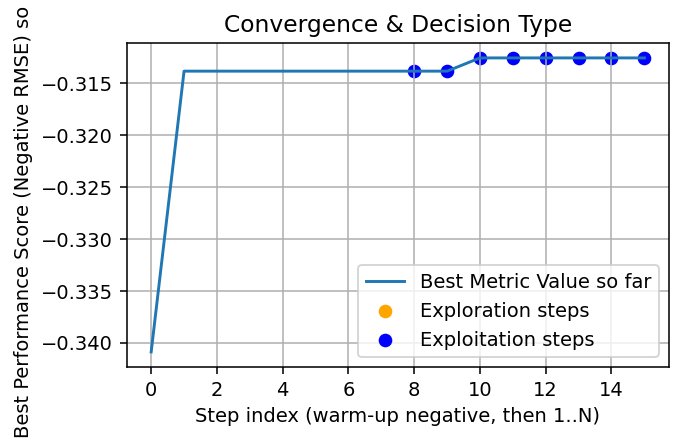

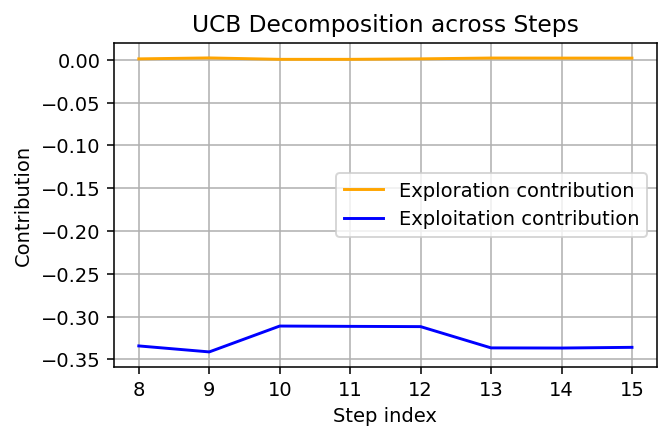

In [16]:
mask_explr = log_df["tag"] == "UCB (Exploration)"; mask_explt = log_df["tag"] == "UCB (Exploitation)"

plt.figure()
plt.plot(log_df["best_metric_value_so_far"], label="Best Metric Value so far")
plt.scatter(log_df.index[mask_explr], log_df.loc[mask_explr, "best_metric_value_so_far"], label="Exploration steps", color="orange")
plt.scatter(log_df.index[mask_explt], log_df.loc[mask_explt, "best_metric_value_so_far"], label="Exploitation steps", color="blue")
plt.xlabel("Step index (warm-up negative, then 1..N)"); plt.ylabel("Best Performance Score (Negative RMSE) so far")
plt.title("Convergence & Decision Type"); plt.legend(); plt.show()

plt.figure()
plt.plot(log_df["explore_contrib"], label="Exploration contribution",color="orange")
plt.plot(log_df["exploit_contrib"], label="Exploitation contribution", color="blue")
plt.xlabel("Step index"); plt.ylabel("Contribution")
plt.title("UCB Decomposition across Steps"); plt.legend(); plt.show()

In [17]:
print(f"Baseline Negative RMSE: {-baseline_rmse:.4f}")
print(f"Best Performance Score (Max Negative RMSE) found: {log_df['best_metric_value_so_far'].max():.4f}")

Baseline Negative RMSE: -0.4579
Best Performance Score (Max Negative RMSE) found: -0.3126


#### Surrogate slice: initial vs final (learning_rate)
Fits a Gaussian Process surrogate on the current trials (X_used, y_used)

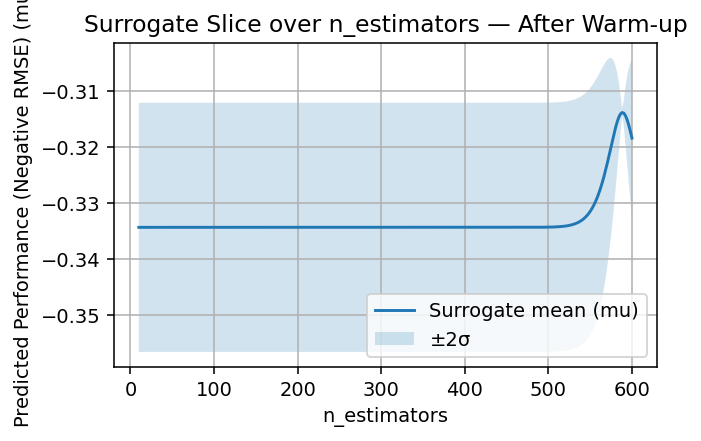

--- After Warm-up over n_estimators ---
Range of lower 2-sigma bound: [-0.3566, -0.3146]
Range of upper 2-sigma bound: [-0.3131, -0.3041]



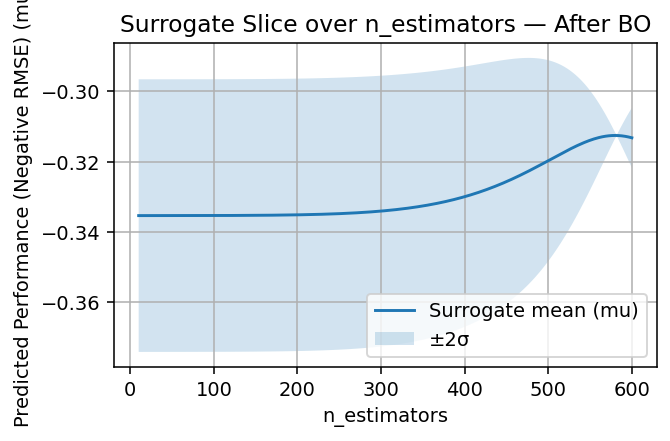

--- After BO over n_estimators ---
Range of lower 2-sigma bound: [-0.3742, -0.3129]
Range of upper 2-sigma bound: [-0.3123, -0.2905]



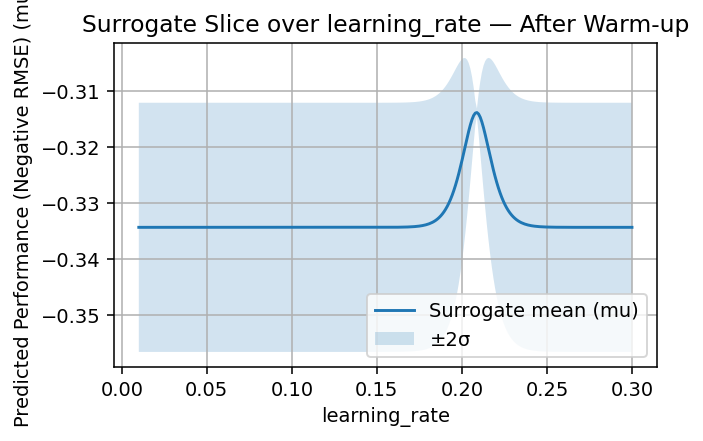

--- After Warm-up over learning_rate ---
Range of lower 2-sigma bound: [-0.3566, -0.3145]
Range of upper 2-sigma bound: [-0.3131, -0.3041]



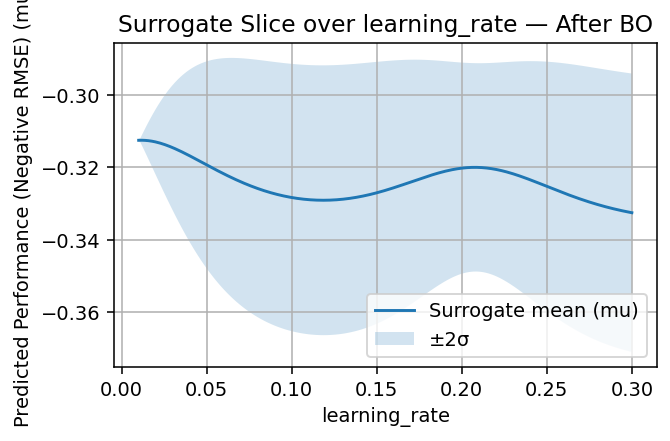

--- After BO over learning_rate ---
Range of lower 2-sigma bound: [-0.3709, -0.3130]
Range of upper 2-sigma bound: [-0.3121, -0.2899]



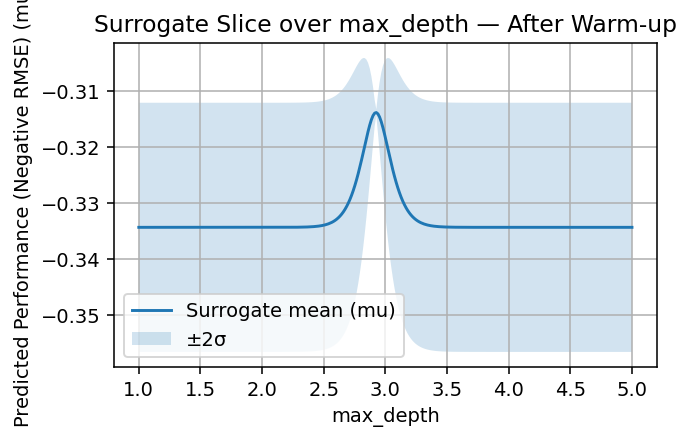

--- After Warm-up over max_depth ---
Range of lower 2-sigma bound: [-0.3566, -0.3144]
Range of upper 2-sigma bound: [-0.3132, -0.3041]



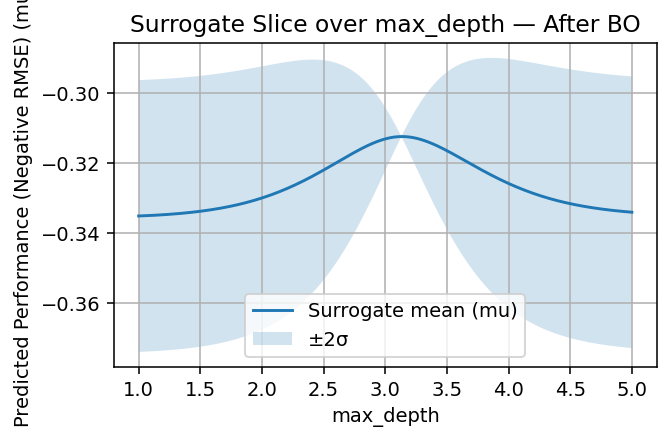

--- After BO over max_depth ---
Range of lower 2-sigma bound: [-0.3741, -0.3129]
Range of upper 2-sigma bound: [-0.3123, -0.2901]



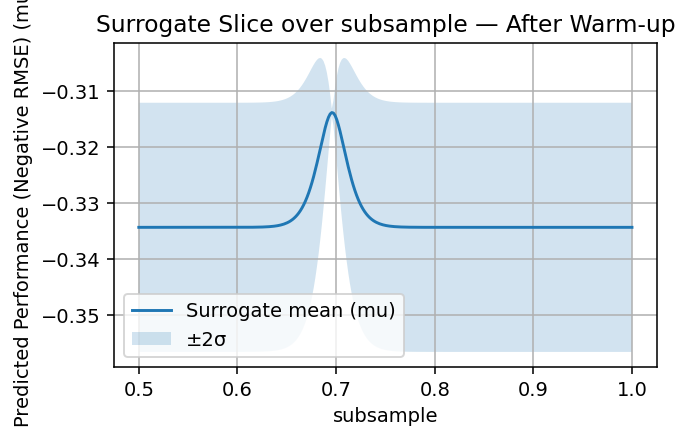

--- After Warm-up over subsample ---
Range of lower 2-sigma bound: [-0.3566, -0.3146]
Range of upper 2-sigma bound: [-0.3131, -0.3041]



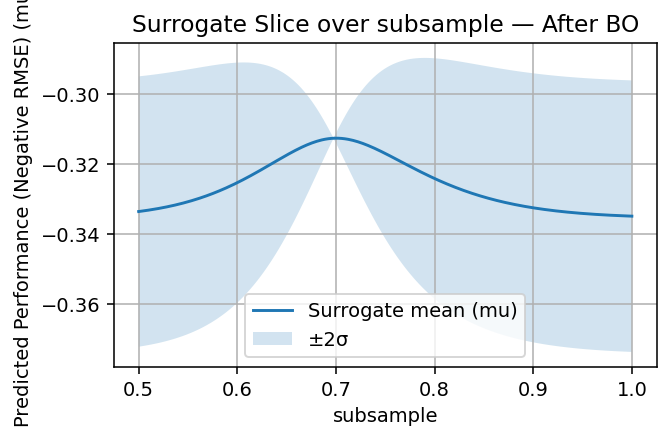

--- After BO over subsample ---
Range of lower 2-sigma bound: [-0.3736, -0.3128]
Range of upper 2-sigma bound: [-0.3123, -0.2896]



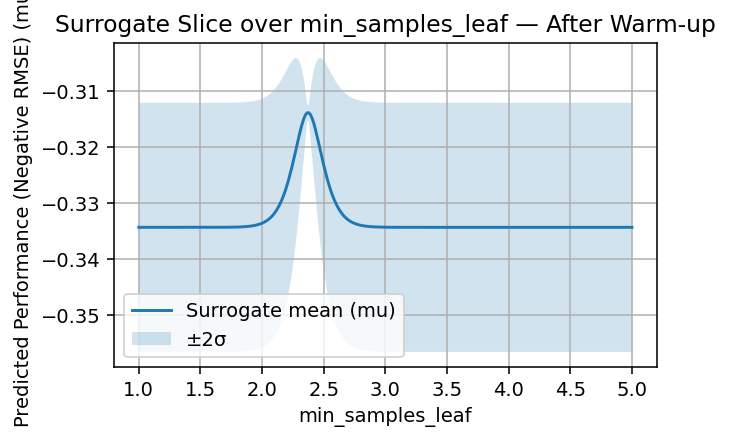

--- After Warm-up over min_samples_leaf ---
Range of lower 2-sigma bound: [-0.3566, -0.3150]
Range of upper 2-sigma bound: [-0.3127, -0.3041]



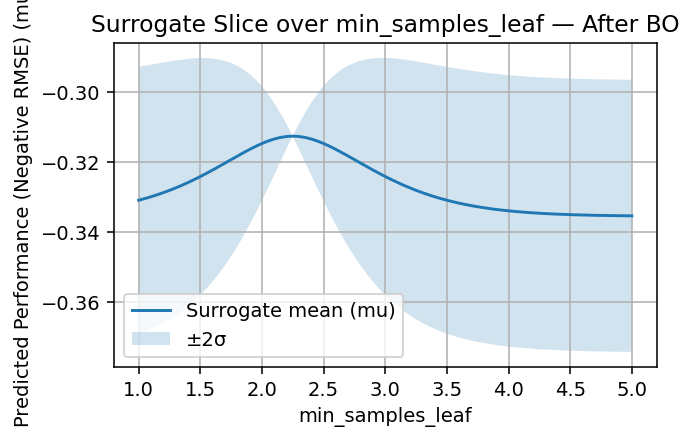

--- After BO over min_samples_leaf ---
Range of lower 2-sigma bound: [-0.3741, -0.3129]
Range of upper 2-sigma bound: [-0.3122, -0.2902]



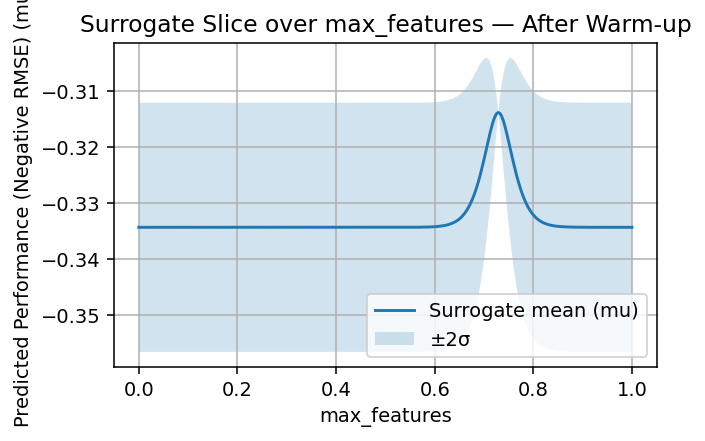

--- After Warm-up over max_features ---
Range of lower 2-sigma bound: [-0.3566, -0.3139]
Range of upper 2-sigma bound: [-0.3137, -0.3041]



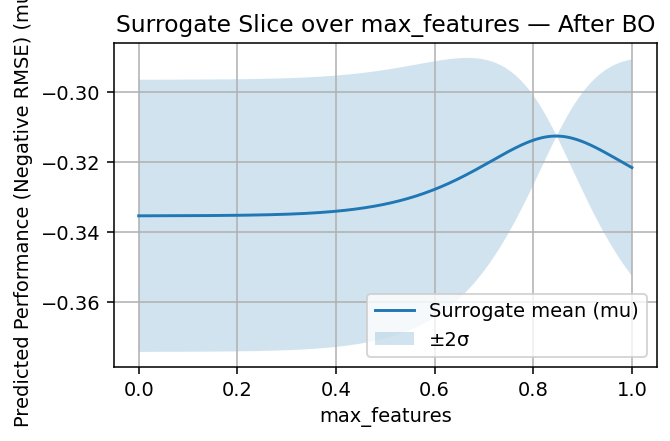

--- After BO over max_features ---
Range of lower 2-sigma bound: [-0.3742, -0.3130]
Range of upper 2-sigma bound: [-0.3121, -0.2903]



In [18]:
def surrogate_slice_plot(X_used, y_used, title_suffix, hp_name_to_plot):
    gp = GaussianProcessRegressor(kernel=C(1.0)*Matern(nu=2.5)+WhiteKernel(1e-6), normalize_y=True, random_state=0)
    gp.fit(X_used, y_used)

    # Best trial so far (max of negative RMSE)
    best_idx = np.argmax(y_used); anchor = X_used[best_idx].copy()
    j = list(space.keys()).index(hp_name_to_plot)
    xs = np.linspace(0,1,300); grid = np.tile(anchor, (len(xs),1)); grid[:, j] = xs
    mu, std = gp.predict(grid, return_std=True)
    lo, hi = space[hp_name_to_plot]; hp_vals = lo + xs*(hi-lo)

    plt.figure()
    plt.plot(hp_vals, mu, label="Surrogate mean (mu)")
    plt.fill_between(hp_vals, mu-2*std, mu+2*std, alpha=0.2, label="±2σ")
    plt.xlabel(hp_name_to_plot); plt.ylabel("Predicted Performance (Negative RMSE) (mu)")
    plt.title(f"Surrogate Slice over {hp_name_to_plot} — {title_suffix}")
    plt.legend(); plt.show()

    # Calculate and print the ranges of the 2 sigmas
    lower_bound = mu - 2 * std
    upper_bound = mu + 2 * std
    print(f"--- {title_suffix} over {hp_name_to_plot} ---")
    print(f"Range of lower 2-sigma bound: [{np.min(lower_bound):.4f}, {np.max(lower_bound):.4f}]")
    print(f"Range of upper 2-sigma bound: [{np.min(upper_bound):.4f}, {np.max(upper_bound):.4f}]\n")

X_warm = np.array([r for r in globals()['X_trials'][:N_INIT]])
y_warm = np.array([objective(to_params(x)) for x in X_warm])

for hp_name in hp:
    surrogate_slice_plot(X_warm, y_warm, "After Warm-up", hp_name)
    surrogate_slice_plot(globals()['X_trials'], globals()['y_trials'], "After BO", hp_name)

### Final Model (on best parameters)

** Weekly Strategy**

1. **Week 4** using a KAPPA of 200.0, the next best candidate offered was [0.981147, 0.877015, 0.205525, 0.304759, 0.558392, 0.496625]
2. **Week 5**, using a KAPPA of 500.0, the next best candidate is [0.31588644, 0.99942374, 0.0206061 , 0.8405964 , 0.10655946, 0.96940121]
3. **Week 6**, using a KAPPA of 1000.0 for more agressive exploration, the next best candidate offered was [0.76677374, 0.04709176, 0.35428874, 0.57157374, 0.29125897, 0.68480789]
4. **Week 7**, using a KAPPA of 5.0 for exploitation, the next best candidate offered was [0.96779742, 0.65404178, 0.30772017, 0.84282304, 0.04004229, 0.98226501], changed n_estimators upper bound from 400 to 600 also after reviewing last two plots

# Hyperameter Tuning Consideration

**For Week 8**

After adding Week 7 data points, and running the iteration for Week 8, I changed the learning rate lower bound to 30 from 50 after reviewing the learning rate vs best rmse plot. I also updated the surrogate slice code to review After Warm-up plots and After BO plots for each hyperparameter. I also changed the KAPPA to 2.0 as I thought I could achieve a better rmse if I did more aggressive exploitation. There was an improvement seen in rmse with a KAPPA of 2.0 compared to 5.0.

**Also after reviewing the residuals plot**,

The residuals plot is highly unusual, showing all predicted values clustered around a single point (approximately 0.2285), with the residuals spread vertically from that point.

This indicates that your GradientBoostingRegressor model is predicting almost the same constant value for all input samples (X). This is a clear sign of severe underfitting.it was showing highly unusual pattern, all modified the space dictionary to allow for more flexible values for min_samples_leaf and max_depth by setting the min_samples_leaf range to (1, 5) and max_depth to (1, 5) to encourage the model to capture more patterns without necessarily overfitting the small dataset.

After making this change the residuals plot looked alot more as expected indicating that underfitting has been addressed.

Week 8 next best candidate offered is [0.95028572, 0.85035952, 0.66326173, 0.06687274, 0.15063519, 0.10752667]

**Week 9 using a KAPPA of 0.1 from BO**
 - Suggested next X data point (6D coordinates): [0.47796668 0.07150154 0.24662232 0.56658058 0.183852   0.24766705]
 - Predicted Y at this point (mean, Negative RMSE): 2.06439e-01
 - Predicted uncertainty (std) at this point: 2.91324e-01
 - UCB value at this point: 2.35572e-01

**Week 10 using a KAPPA of 0.25 from BO**

 - Suggested next X data point (6D coordinates): [0.06515925 0.4345162  0.92221942 0.31349042 0.38793978 0.76627365]
 - Predicted Y at this point (mean, Negative RMSE): 1.32951e+00
 - Predicted uncertainty (std) at this point: 1.03388e-01
 - UCB value at this point: 1.35536e+00


**Week 11 using a KAPPA of 0.1 from BO and changing hyperparamters    n_estimators reduced to 10 from 30**

 - Suggested next X data point (6D coordinates): [0.02629769 0.43945733 0.03456813 0.14030379 0.33397116 0.79124682]
 - Predicted Y at this point (mean, Negative RMSE): 1.37388e+00
 - Predicted uncertainty (std) at this point: 1.27627e-01
 - UCB value at this point: 1.38664e+00

**Week 12 using a KAPPA of 0.1 from BO**

 - Suggested next X data point (6D coordinates): [0.73143932 0.69288661 0.91856304 0.15642207 0.39759442 0.75230542]
 - Predicted Y at this point (mean, Negative RMSE): 1.37651e+00
 - Predicted uncertainty (std) at this point: 5.94474e-02
 - UCB value at this point: 1.38245e+00

**Week 13 using a KAPPA of 0.1 from BO**

 - Suggested next X data point (6D coordinates): [0.03798112 0.43531752 0.28714547 0.63566807 0.44754276 0.73915955]
 - Predicted Y at this point (mean, Negative RMSE): 1.35950e+00
 - Predicted uncertainty (std) at this point: 5.12125e-02
 - UCB value at this point: 1.36462e+00

Optimized hyperparameters (from BO): {'n_estimators': 582, 'learning_rate': 0.010437662460820334, 'max_depth': 3, 'subsample': 0.6975535635983554, 'min_samples_leaf': 2, 'max_features': 'log2'}
Final (BO) 5-fold RMSE: 0.313


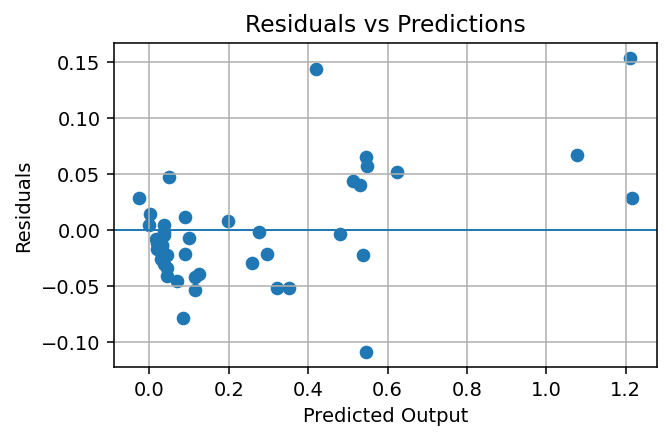

In [19]:
# The original values for max_depth and subsample were fixed within the objective function.
# We need to use those same fixed values here to initialize the final model.
# However, with the 5D optimization, max_depth and subsample are now optimized by BO.
# We should use the optimized values from best_params for the final model.

best_row = log_df.iloc[log_df["best_metric_value_so_far"].idxmax()]
best_params = {}
for k in space.keys():
    if k == "max_features":
        best_params[k] = best_row[k] # Keep as string
    else:
        best_params[k] = float(best_row[k])

# Ensure integer hyperparameters are correctly cast
best_params["n_estimators"] = int(best_params["n_estimators"])
best_params["max_depth"] = int(best_params["max_depth"])
best_params["min_samples_leaf"] = int(best_params["min_samples_leaf"])

print("Optimized hyperparameters (from BO):", best_params)

final = GradientBoostingRegressor(
    n_estimators=best_params["n_estimators"],
    learning_rate=best_params["learning_rate"],
    max_depth=best_params["max_depth"], # Use the BO-optimized value
    subsample=best_params["subsample"], # Use the BO-optimized value
    min_samples_leaf=best_params["min_samples_leaf"],
    max_features=best_params["max_features"], # Use the BO-optimized value (string 'sqrt' or 'log2')
    random_state=42
)
final_rmse = rmse_cv(final)
print("Final (BO) 5-fold RMSE:", round(final_rmse, 3))

final.fit(X, y)
pred = final.predict(X)
resid = y - pred # Corrected: subtract predictions from actual target values (y)

plt.figure()
plt.scatter(pred, resid)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted Output"); plt.ylabel("Residuals") # Changed label for generality
plt.title("Residuals vs Predictions")
plt.show()

**Week 8**

The residuals plot is highly unusual, showing all predicted values clustered around a single point (approximately 0.2285), with the residuals spread vertically from that point. This indicates that your GradientBoostingRegressor model is predicting almost the same constant value for all input samples (X). This is a clear sign of severe underfitting.

**Implications:**

### Model is not learning: The model is effectively not capturing any relationships between your input features (X) and the target variable (y). It's essentially acting like a simple baseline model that predicts the mean of y for every input.

### No predictive power: A model that predicts a constant value has no predictive power and cannot generalize to new, unseen data.

Possible causes:

Over-regularisation or too simple model:

The hyperparameters chosen by Bayesian Optimisation, specifically min_samples_leaf (14) and max_depth (2) for a dataset with only 37 samples, are likely too restrictive.

With min_samples_leaf set to 14, each split in a tree would require at least 14 samples in each child node. For a dataset of only 37 samples, this might prevent the trees from splitting much, if at all, resulting in very shallow and uninformative trees.

To address this, I have modified the space dictionary to allow for more flexible values for min_samples_leaf and max_depth. I'm setting the min_samples_leaf range to (1, 5) and max_depth to (1, 5) to encourage the model to capture more patterns without necessarily overfitting the small dataset.

### Log review (each step)

In [20]:
try:
    import caas_jupyter_tools as cj
    subset_cols = ["iter","tag","metric_value","best_metric_value_so_far","mu","sigma","ei","exploit_contrib","explore_contrib"] + list(space.keys())
    log_view = log_df[subset_cols].round(4)
    cj.display_dataframe_to_user("BayesOpt_Step_Log", log_view)
except Exception:
    pass

log_df.head(20)

,iter,tag,metric_value,best_metric_value_so_far,mu,sigma,ei,exploit_contrib,explore_contrib,n_estimators,learning_rate,max_depth,subsample,min_samples_leaf,max_features
0,-7,Warm-up,-0.340905,-0.340905,NaN,NaN,NaN,NaN,NaN,421.0,0.092980,2.0,0.775657,4.0,sqrt
1,-6,Warm-up,-0.313837,-0.313837,NaN,NaN,NaN,NaN,NaN,589.0,0.208601,3.0,0.696059,2.0,log2
2,-5,Warm-up,-0.321025,-0.313837,NaN,NaN,NaN,NaN,NaN,269.0,0.027307,3.0,0.868998,2.0,sqrt
3,-4,Warm-up,-0.343509,-0.313837,NaN,NaN,NaN,NaN,NaN,324.0,0.164230,4.0,0.924716,4.0,log2
4,-3,Warm-up,-0.347654,-0.313837,NaN,NaN,NaN,NaN,NaN,436.0,0.103658,2.0,0.614132,2.0,log2
5,-2,Warm-up,-0.329003,-0.313837,NaN,NaN,NaN,NaN,NaN,64.0,0.135773,3.0,0.746843,3.0,sqrt
6,-1,Warm-up,-0.341367,-0.313837,NaN,NaN,NaN,NaN,NaN,262.0,0.269083,5.0,0.750918,3.0,sqrt
7,0,Warm-up,-0.337396,-0.313837,NaN,NaN,NaN,NaN,NaN,197.0,0.130300,4.0,0.625228,3.0,log2
8,1,UCB (Exploitation),-0.396674,-0.313837,-0.334268,0.011120,NaN,-0.334268,0.001112,563.0,0.206053,1.0,0.709626,2.0,log2
9,2,UCB (Exploitation),-0.318794,-0.313837,-0.341263,0.022220,NaN,-0.341263,0.002222,133.0,0.186812,3.0,0.846058,2.0,sqrt


# **Suggesting the Next X Data Point using Bayesian Optimization**

To find the next best x (6D coordinates) to optimising an ML model by tuning six hyperparameters, for example learning rate, regularisation strength or number of hidden layers. The function you’re maximising is the model’s performance score (such as accuracy or F1), but since the relationship between inputs and output isn’t known, it’s treated as a black-box function.

Your goal is to find the combination of hyperparameters that yields the highest possible performance.

We will set up a separate Bayesian Optimization process. This process will:

Fit a Gaussian Process Regressor on the existing X (6D coordinates) and y (performance score). Generate a grid of candidate points across the 6D input space. Evaluate an Acquisition Function (like Upper Confidence Bound - UCB) for each candidate point. Identify the candidate point with the highest acquisition function value as the next suggested x for sampling

# Explain the purpose of the 6D candidate search in the below cell
# The purpose of the 6D candidate search is distinct from the Bayesian Optimization process that optimized the hyperparameters of the GradientBoostingRegressor.

Here's the breakdown:

# **Earlier Bayesian Optimization (optimizing hyperparameters):**

**Goal:** To find the best GradientBoostingRegressor settings (n_estimators, learning_rate, max_depth, subsample, min_samples_leaf).

**Input (X for that BO):** The 5 hyperparameters themselves.

**Output (y for that BO):** The RMSE of the Gradient Boosting Regressor trained with those hyperparameters.

**Result:** The best_params for the GradientBoostingRegressor model.


# **5D Candidate Search in the below cell (optimizing cake ingredients):**

**Goal:** To find the best combination of the 5 cake ingredients (X from the initial dataset) to maximize the cake's score (y from the initial dataset).

**Input (X for this BO):** The actual ingredient proportions (the X array you loaded at the beginning).

**Output (y for this BO):** The scores associated with those ingredient combinations (the y array you loaded at the beginning).

**Result:** next_x_data_point, which is a suggested new 6D combination of hyperparameters that yeilds the best performance score.

In essence, the first BO helps us build a better predictive model, and the second BO in the above cell uses a similar technique but is applied to the original problem data to directly suggest better inputs for that original problem (the cake recipe)

In [21]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
import numpy as np
import matplotlib.pyplot as plt

# The search space for the 6D input features (hyperparameters for the ML model)
# X values represent normalized hyperparameter values between [0, 1]

d_x = X.shape[1] # Dimension of the X input space (should be 6 for the hyperparameters)

# 2. Initialize and fit a Gaussian Process Regressor on the existing data
# We'll use the same kernel structure as for hyperparameter optimization, but applied to the X, y data
# Note: Normalizing y is crucial for GP performance
kernel_3d = C(1.0, (1e-3, 1e3)) * Matern(length_scale=np.ones(d_x), nu=2.5) + WhiteKernel(noise_level=1e-6, noise_level_bounds=(1e-9, 1e-2))
gpr_3d = GaussianProcessRegressor(kernel=kernel_3d, normalize_y=True, random_state=42, n_restarts_optimizer=3)

gpr_3d.fit(X, y)

# 3. Generate a grid of candidate points across the 6D input space
n_candidates_3d = 10000 # Number of candidate points for the 6D search space

# Create a uniform grid of candidates within the defined bounds [0,1] for all six features
candidates_3d = np.random.rand(n_candidates_3d, d_x)

# 4. Predict mean and standard deviation for these candidates
mu_3d, std_3d = gpr_3d.predict(candidates_3d, return_std=True)

# 5. Compute the Upper Confidence Bound (UCB) acquisition function for MAXIMIZATION
# We need to decide on a KAPPA for this 6D search. A higher KAPPA means more exploration.
KAPPA_3D = KAPPA # You can adjust this value to control exploration vs. exploitation for the 6D space

# Since we are trying to MAXIMIZE the output (Negative RMSE),
# UCB is calculated as mu + KAPPA * std
ucb_acquisition = mu_3d + KAPPA_3D * std_3d

# 6. Identify the candidate point with the MAXIMUM UCB
best_ucb_idx = np.argmax(ucb_acquisition)
next_x_data_point = candidates_3d[best_ucb_idx]
predicted_y_at_next_x = mu_3d[best_ucb_idx]
predicted_std_at_next_x = std_3d[best_ucb_idx]

print(f"Suggested next X data point (6D coordinates): {next_x_data_point}")
print(f"Predicted Y at this point (mean, Negative RMSE): {predicted_y_at_next_x:.5e}")
print(f"Predicted uncertainty (std) at this point: {predicted_std_at_next_x:.5e}")
print(f"UCB value at this point: {ucb_acquisition[best_ucb_idx]:.5e}")

# For 6D data, direct 2D visualization is not appropriate for all features simultaneously.
# Instead of a scatter plot, we'll rely on the printed 6D coordinates.


Suggested next X data point (6D coordinates): [0.00497741 0.53686708 0.41111698 0.25181151 0.403786   0.71868694]
Predicted Y at this point (mean, Negative RMSE): 1.33686e+00
Predicted uncertainty (std) at this point: 5.26684e-02
UCB value at this point: 1.34212e+00


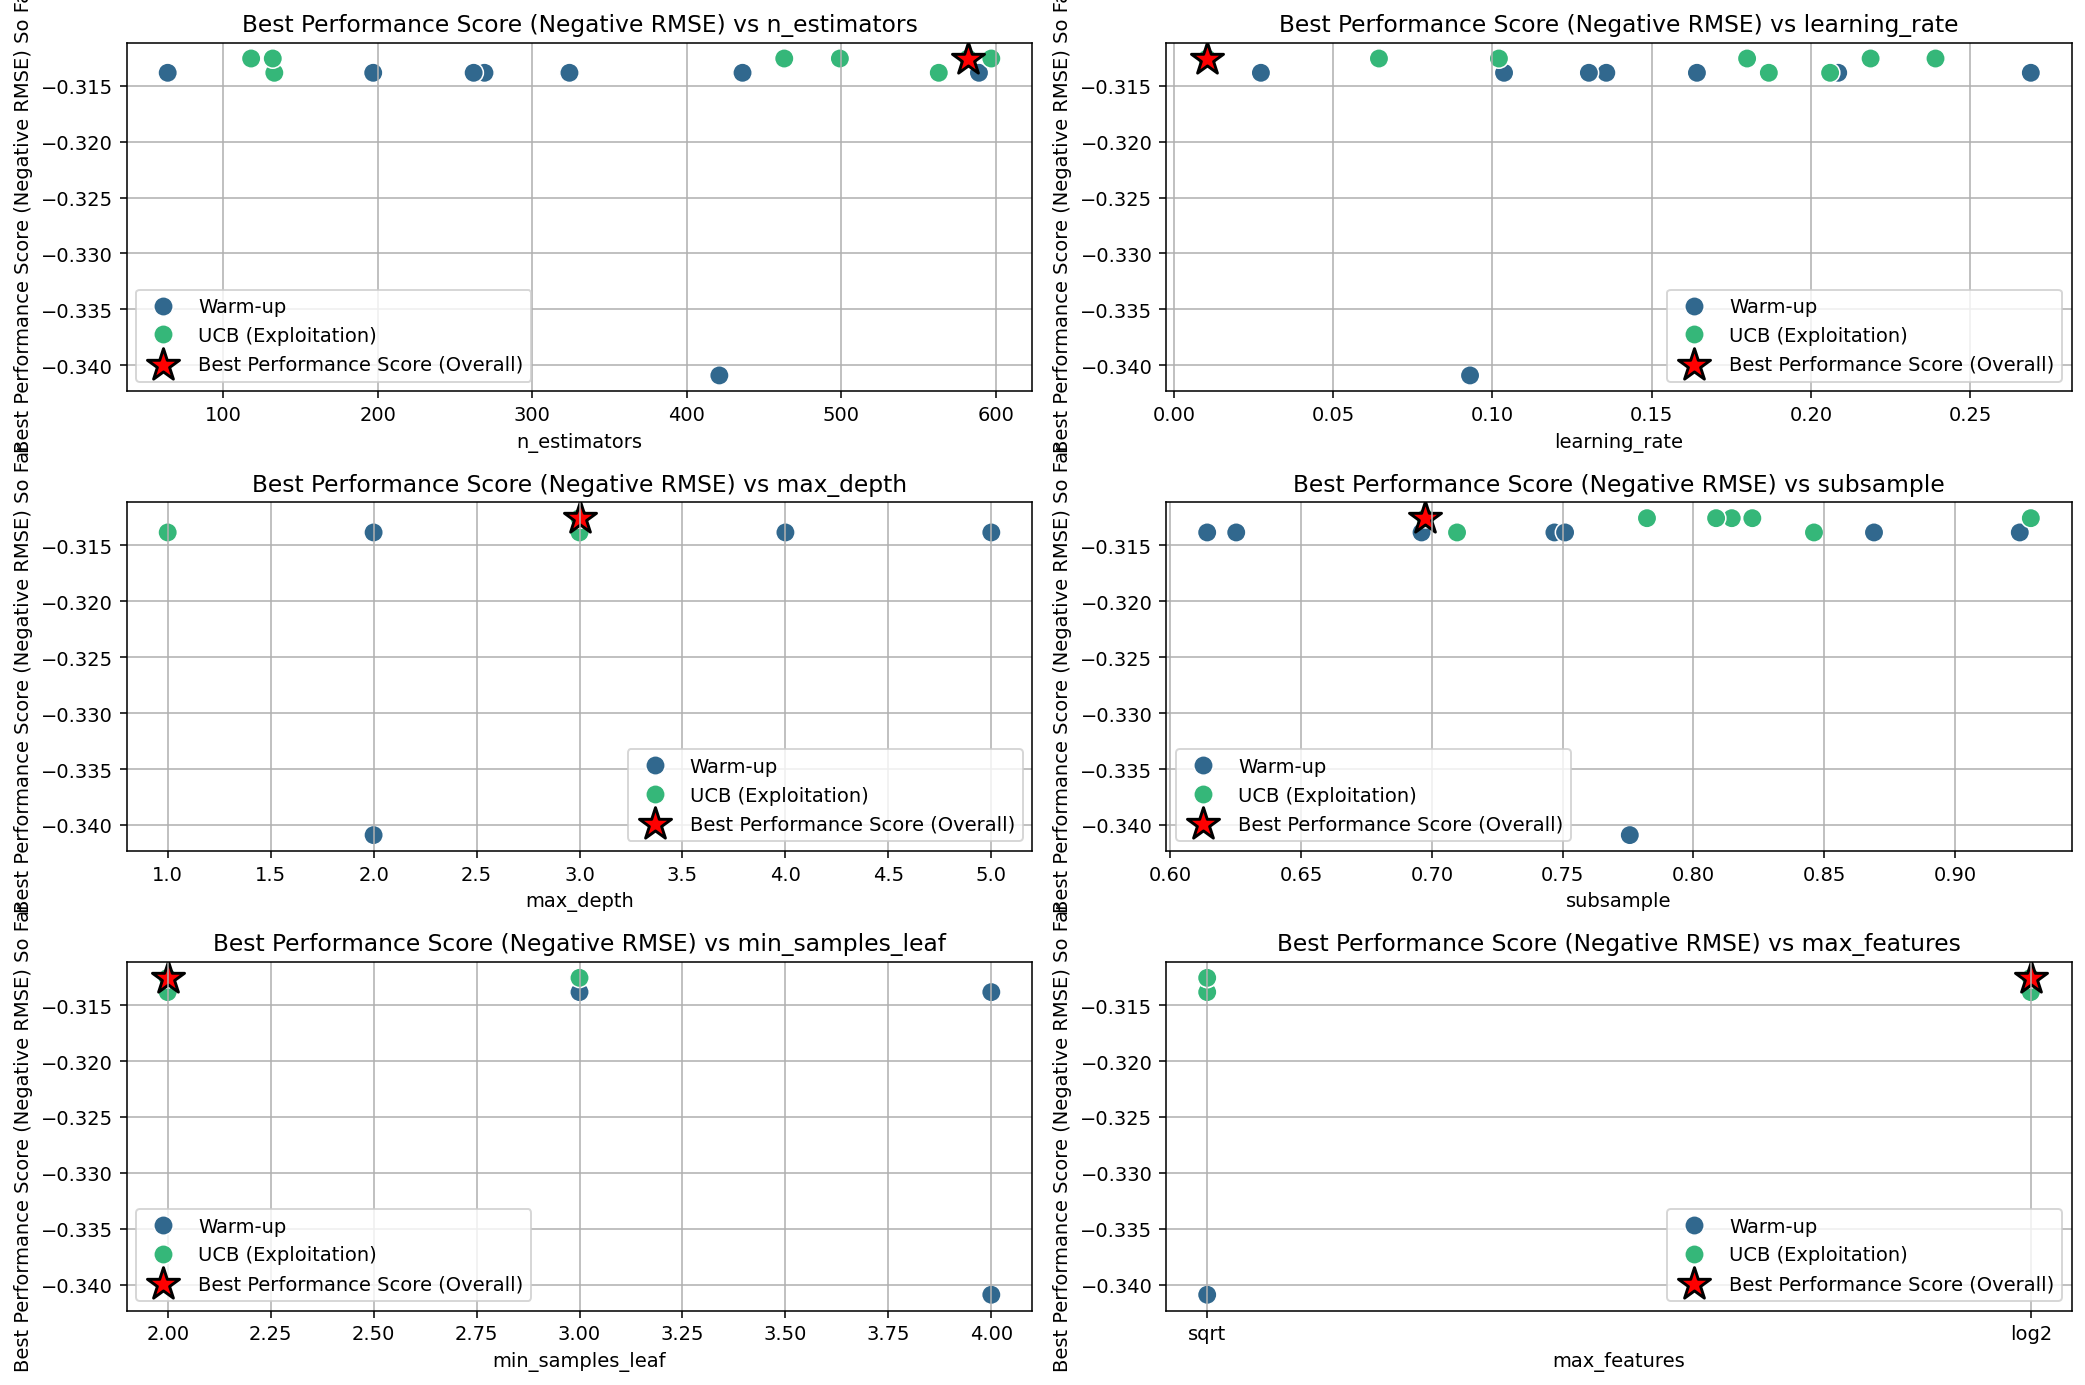

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

hyperparameters = list(space.keys())

plt.figure(figsize=(15, 10))
for i, hp_name in enumerate(hyperparameters):
    plt.subplot(3, 2, i + 1) # Changed to 3x2 grid to accommodate 5 plots
    sns.scatterplot(data=log_df, x=hp_name, y='best_metric_value_so_far', hue='tag', palette='viridis', s=100)

    # Get the best Performance Score (Max Negative RMSE) and its corresponding row across all hyperparameters
    best_metric_val_overall = log_df['best_metric_value_so_far'].max()
    best_row = log_df[log_df['best_metric_value_so_far'] == best_metric_val_overall].iloc[0]

    # Highlight the best overall Performance Score point for the current hyperparameter
    best_hp_value = best_row[hp_name]
    best_metric_value = best_row['best_metric_value_so_far']
    plt.scatter(best_hp_value, best_metric_value, color='red', marker='*', s=300, edgecolor='black', linewidth=1.5, label='Best Performance Score (Overall)')

    plt.title(f'Best Performance Score (Negative RMSE) vs {hp_name}')
    plt.xlabel(hp_name)
    plt.ylabel('Best Performance Score (Negative RMSE) So Far')
    plt.grid(True)
    if hp_name in ['n_estimators', 'max_depth']:
        plt.ticklabel_format(useOffset=False, style='plain', axis='x') # Prevent scientific notation for integer axes
    plt.legend()

plt.tight_layout()
plt.show()

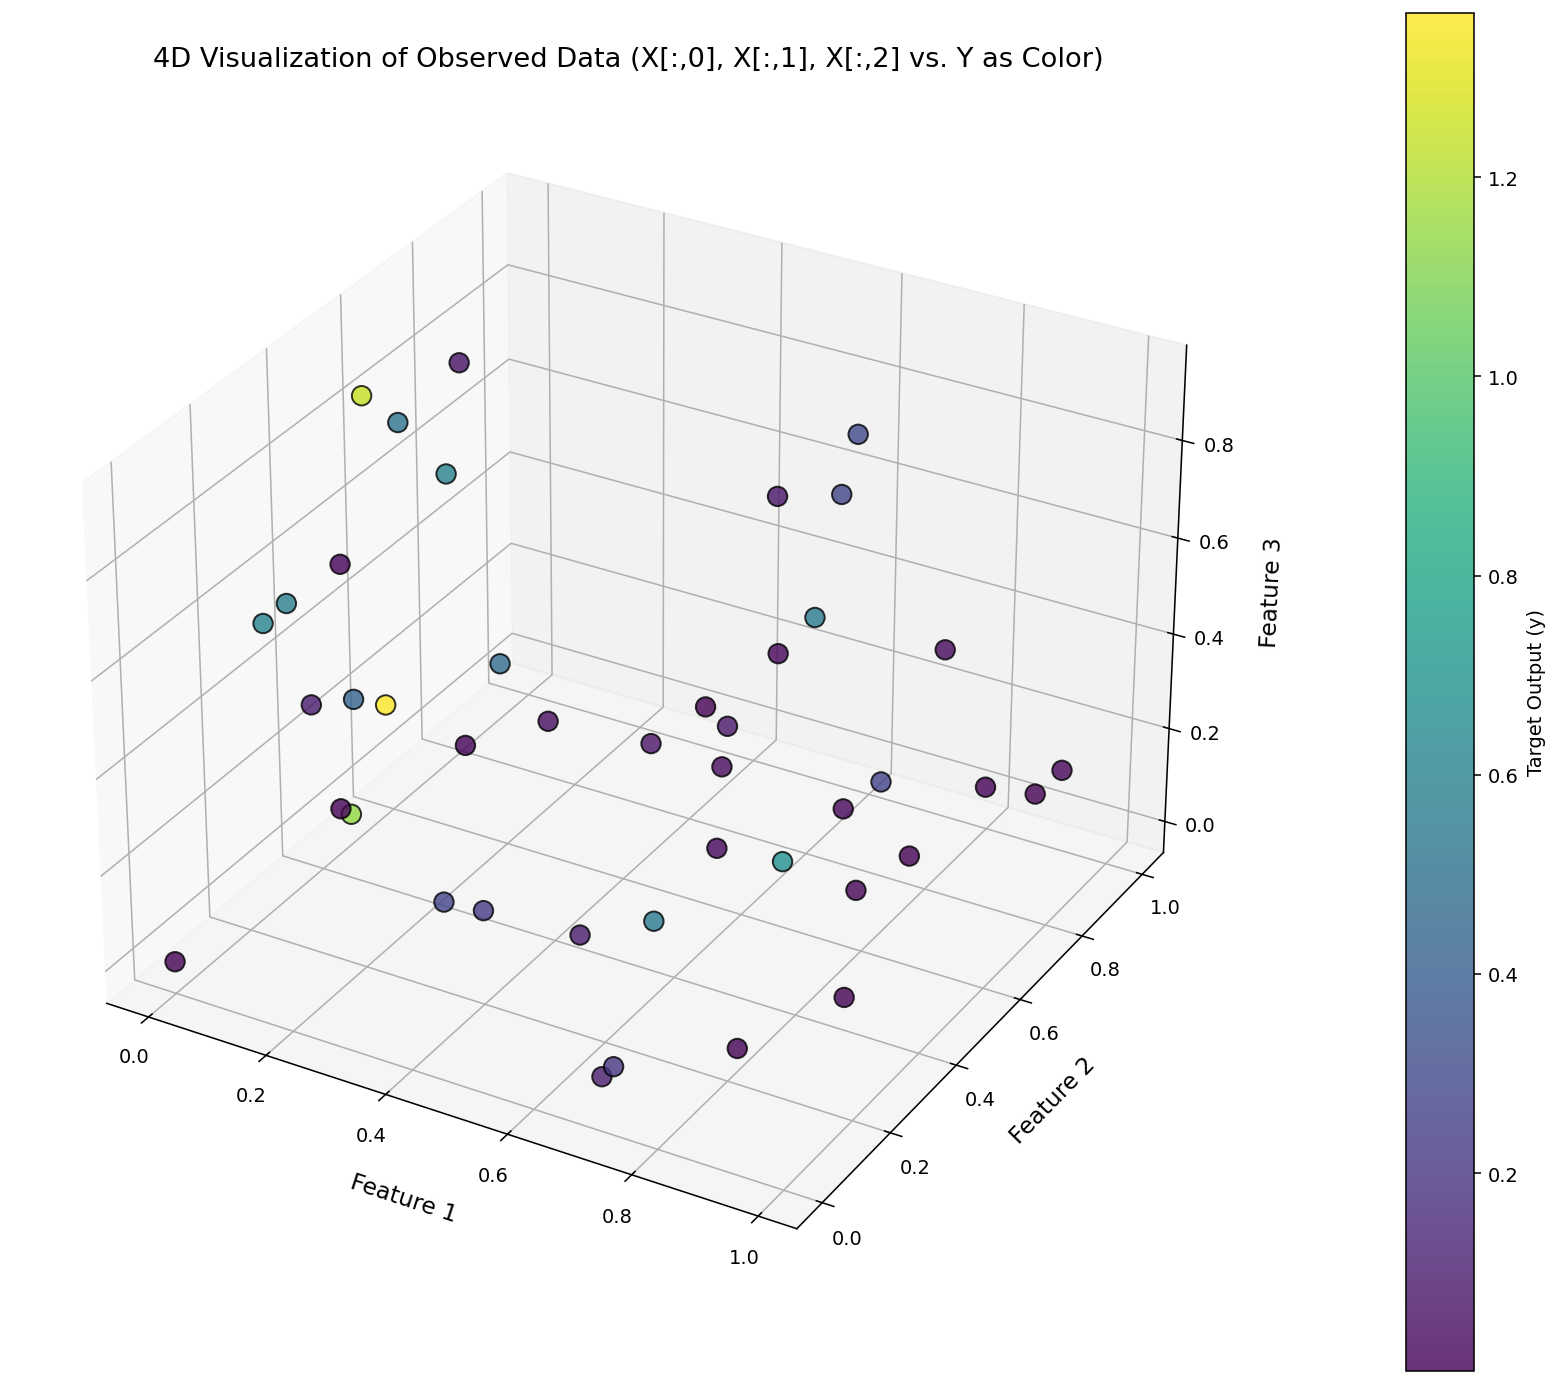

Displayed: 4D Scatter Plot of Observed Data (first 3 features)


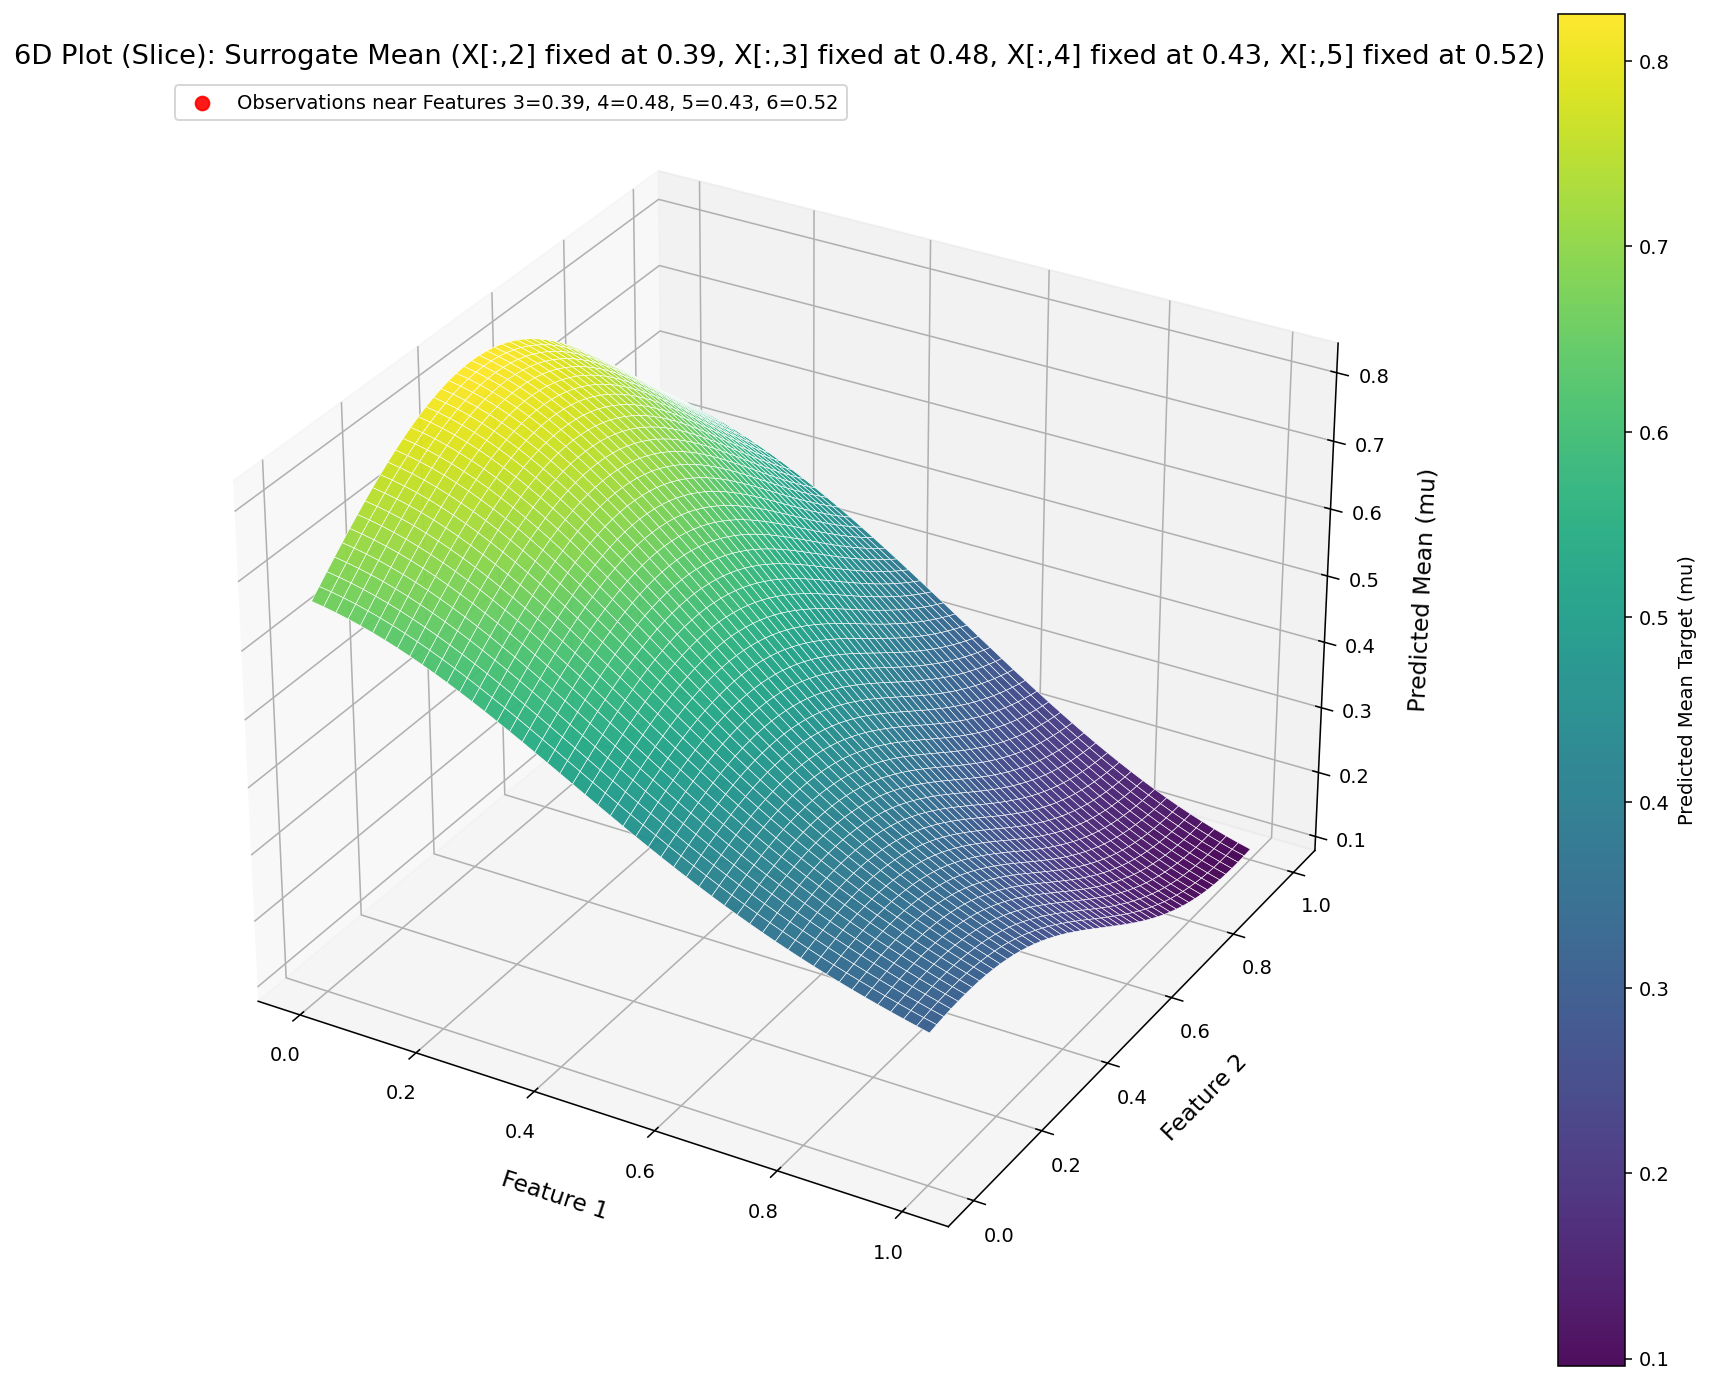

Displayed: 6D Slice Plot for Surrogate Mean (Features 3 fixed at 0.39, 4 fixed at 0.48, 5 fixed at 0.43, 6 fixed at 0.52)


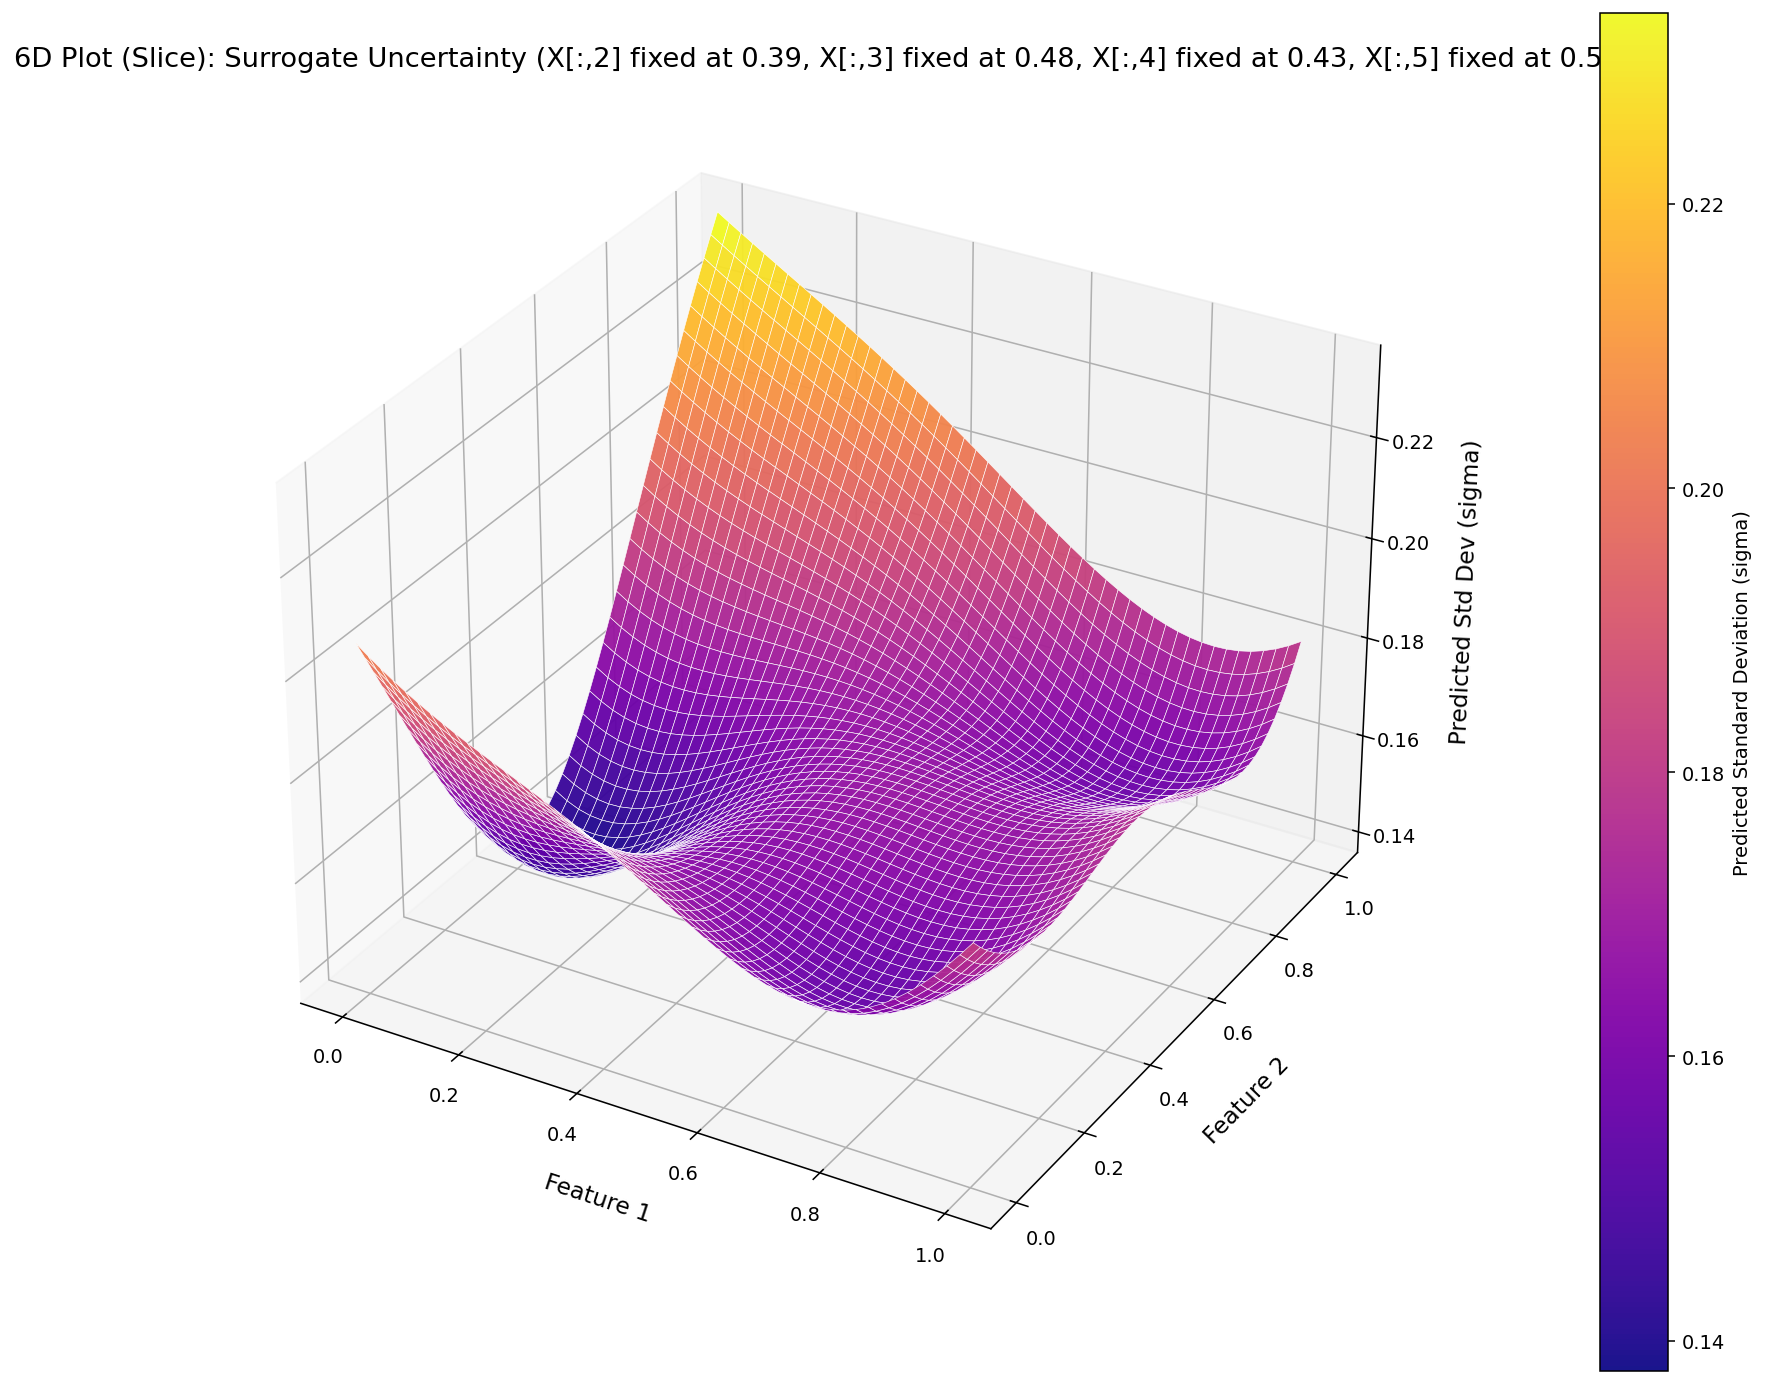

Displayed: 6D Slice Plot for Surrogate Uncertainty (Features 3 fixed at 0.39, 4 fixed at 0.48, 5 fixed at 0.43, 6 fixed at 0.52)


In [23]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel as C
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

resolution = 50 # Reduced resolution for faster plotting of slices

# The gpr_3d model was defined and fitted in cell 'qd_rPFSHpykn'
gp = gpr_3d

# Observed data
X_obs = X # Global variable X from the notebook state (6D input)
y_obs = y # Global variable y from the notebook state (1D output)

# ───────────────────────────────
# 1. 4D Plot: 3D Scatter Plot of Observations with Color representing Y
#    (Visualizing the first 3 features and the target Y)
# ───────────────────────────────
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Create a colormap based on the range of y_obs values
scatter = ax.scatter(
    X_obs[:, 0], X_obs[:, 1], X_obs[:, 2],
    c=y_obs, # Color represents the 4th dimension (y_obs)
    cmap='viridis', # Choose a colormap
    s=100, # Marker size
    edgecolor='k', # Black edge for markers
    alpha=0.8
)

# Add a color bar
cbar = fig.colorbar(scatter, ax=ax, pad=0.1)
cbar.set_label('Target Output (y)')

ax.set_title('4D Visualization of Observed Data (X[:,0], X[:,1], X[:,2] vs. Y as Color)', fontsize=14)
ax.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax.set_zlabel('Feature 3', fontsize=12, labelpad=10)
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('observed_data_4d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print("Displayed: 4D Scatter Plot of Observed Data (first 3 features)")

# ───────────────────────────────
# 2. 5D Plot (Slice): Surrogate Mean Surface by fixing Features 3, 4, 5 and 6
#    This shows a 3D slice of the 6D surrogate function (2 inputs + 1 output)
# ───────────────────────────────
fig2 = plt.figure(figsize=(12, 10))
ax2 = fig2.add_subplot(111, projection='3d')

# Define ranges for the two features we will vary
x1_min, x1_max = 0, 1
x2_min, x2_max = 0, 1

# Create a grid for X[:,0] and X[:,1]
x1_grid = np.linspace(x1_min, x1_max, resolution)
x2_grid = np.linspace(x2_min, x2_max, resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Fix Feature 3 (X[:,2]), Feature 4 (X[:,3]), Feature 5 (X[:,4]), and Feature 6 (X[:,5]) at their mean values
fixed_x3_value = np.mean(X_obs[:, 2])
fixed_x4_value = np.mean(X_obs[:, 3])
fixed_x5_value = np.mean(X_obs[:, 4])
fixed_x6_value = np.mean(X_obs[:, 5])

# Create the 6D input grid for prediction for this slice
# Each point will be [X1_val, X2_val, fixed_x3_value, fixed_x4_value, fixed_x5_value, fixed_x6_value]
X_slice_grid = np.column_stack([X1.ravel(), X2.ravel(),
                                np.full(X1.size, fixed_x3_value),
                                np.full(X1.size, fixed_x4_value),
                                np.full(X1.size, fixed_x5_value),
                                np.full(X1.size, fixed_x6_value)])

# Predict mean and std for this slice from the GPR
mu_slice, std_slice = gp.predict(X_slice_grid, return_std=True)
Mu_slice_surface = mu_slice.reshape(resolution, resolution)
Std_slice_surface = std_slice.reshape(resolution, resolution)

# Plot the surrogate mean surface
surf_mean = ax2.plot_surface(
    X1, X2, Mu_slice_surface,
    cmap='viridis',
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observed points that are close to the fixed feature values
tolerance = 0.1 # Define a tolerance for "close"
close_points_mask = ((X_obs[:, 2] >= fixed_x3_value - tolerance) & (X_obs[:, 2] <= fixed_x3_value + tolerance)) & \
                    ((X_obs[:, 3] >= fixed_x4_value - tolerance) & (X_obs[:, 3] <= fixed_x4_value + tolerance)) & \
                    ((X_obs[:, 4] >= fixed_x5_value - tolerance) & (X_obs[:, 4] <= fixed_x5_value + tolerance)) & \
                    ((X_obs[:, 5] >= fixed_x6_value - tolerance) & (X_obs[:, 5] <= fixed_x6_value + tolerance))
ax2.scatter(
    X_obs[close_points_mask, 0], X_obs[close_points_mask, 1], y_obs[close_points_mask],
    color='red', s=50, zorder=5, label=f'Observations near Features 3={fixed_x3_value:.2f}, 4={fixed_x4_value:.2f}, 5={fixed_x5_value:.2f}, 6={fixed_x6_value:.2f}', alpha=0.9
)


# Add a color bar for the surface
cbar_mean = fig2.colorbar(surf_mean, ax=ax2, pad=0.1)
cbar_mean.set_label('Predicted Mean Target (mu)')

ax2.set_title(f'6D Plot (Slice): Surrogate Mean (X[:,2] fixed at {fixed_x3_value:.2f}, X[:,3] fixed at {fixed_x4_value:.2f}, X[:,4] fixed at {fixed_x5_value:.2f}, X[:,5] fixed at {fixed_x6_value:.2f})', fontsize=14)
ax2.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax2.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax2.set_zlabel('Predicted Mean (mu)', fontsize=12, labelpad=10)
ax2.tick_params(axis='both', labelsize=10)
ax2.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.savefig('surrogate_mean_slice_5d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print(f"Displayed: 6D Slice Plot for Surrogate Mean (Features 3 fixed at {fixed_x3_value:.2f}, 4 fixed at {fixed_x4_value:.2f}, 5 fixed at {fixed_x5_value:.2f}, 6 fixed at {fixed_x6_value:.2f})")

# ───────────────────────────────
# 3. 5D Plot (Slice): Surrogate Uncertainty Surface by fixing Features 3, 4, 5 and 6
# ───────────────────────────────
fig3 = plt.figure(figsize=(12, 10))
ax3 = fig3.add_subplot(111, projection='3d')

# Plot the surrogate uncertainty surface
surf_std = ax3.plot_surface(
    X1, X2, Std_slice_surface,
    cmap='plasma', # Good for uncertainty
    edgecolor='white',
    linewidth=0.3,
    alpha=0.95
)

# Scatter the observed points that are close to the fixed_x3_value and fixed_x4_value (optional)
ax3.scatter(
    X_obs[close_points_mask, 0], X_obs[close_points_mask, 1], np.zeros_like(y_obs[close_points_mask]), # Project to Z=0 for context
    color='red', s=50, zorder=5, label=f'Observations near Features 3={fixed_x3_value:.2f}, 4={fixed_x4_value:.2f}, 5={fixed_x5_value:.2f}, 6={fixed_x6_value:.2f}', alpha=0.9
)

# Add a color bar for the uncertainty surface
cbar_std = fig3.colorbar(surf_std, ax=ax3, pad=0.1)
cbar_std.set_label('Predicted Standard Deviation (sigma)')

ax3.set_title(f'6D Plot (Slice): Surrogate Uncertainty (X[:,2] fixed at {fixed_x3_value:.2f}, X[:,3] fixed at {fixed_x4_value:.2f}, X[:,4] fixed at {fixed_x5_value:.2f}, X[:,5] fixed at {fixed_x6_value:.2f})', fontsize=14)
ax3.set_xlabel('Feature 1', fontsize=12, labelpad=10)
ax3.set_ylabel('Feature 2', fontsize=12, labelpad=10)
ax3.set_zlabel('Predicted Std Dev (sigma)', fontsize=12, labelpad=10)
ax3.tick_params(axis='both', labelsize=10)
plt.tight_layout()
plt.savefig('surrogate_uncertainty_slice_5d.png', dpi=300, bbox_inches='tight') # Save the plot
plt.show()
print(f"Displayed: 6D Slice Plot for Surrogate Uncertainty (Features 3 fixed at {fixed_x3_value:.2f}, 4 fixed at {fixed_x4_value:.2f}, 5 fixed at {fixed_x5_value:.2f}, 6 fixed at {fixed_x6_value:.2f})")


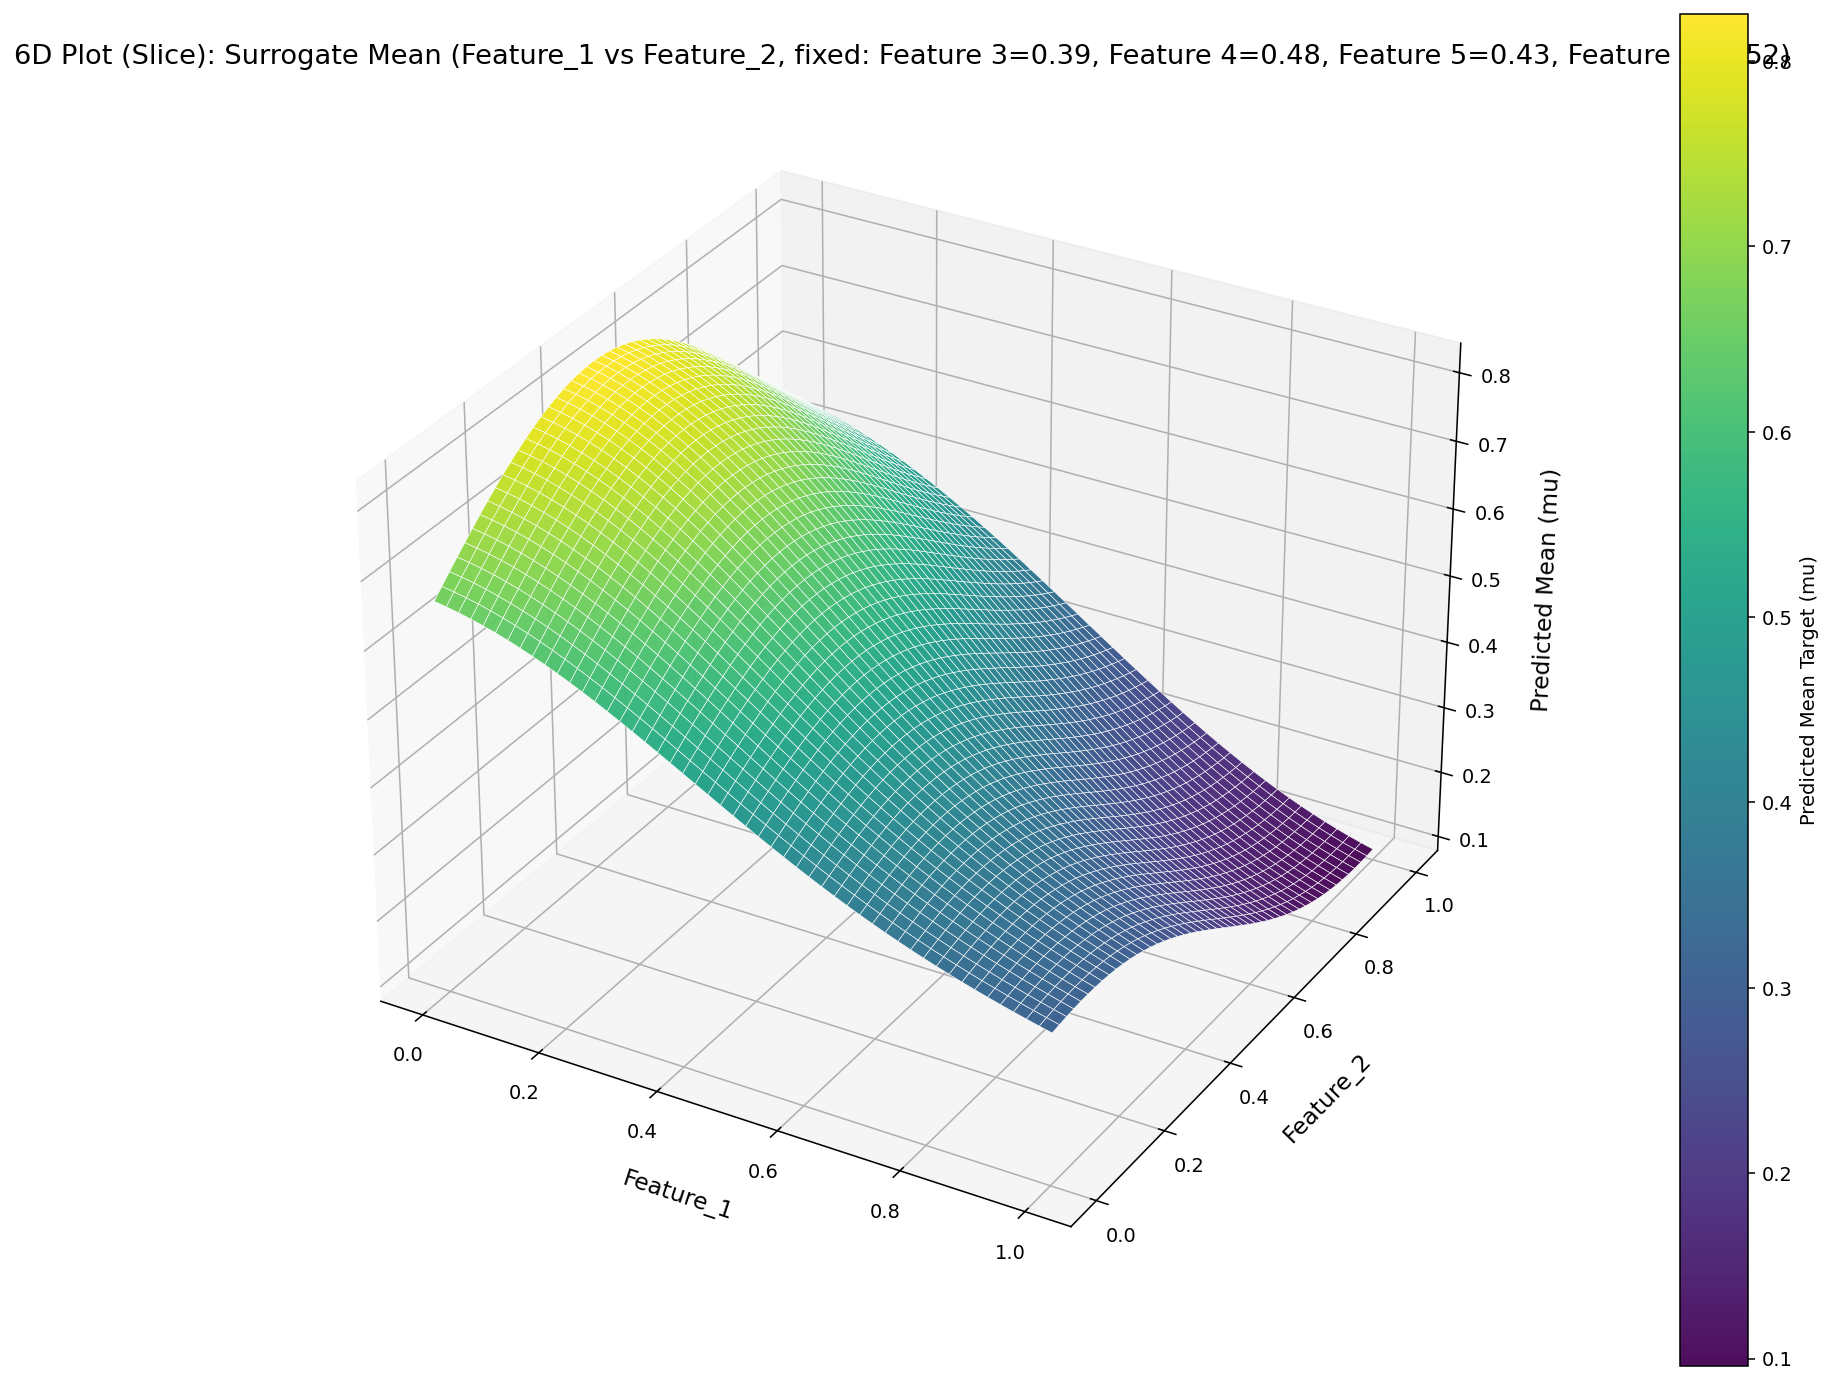

Displayed: 6D Slice Plot for Surrogate Mean (Feature_1 vs Feature_2, fixed: Feature 3=0.39, Feature 4=0.48, Feature 5=0.43, Feature 6=0.52)


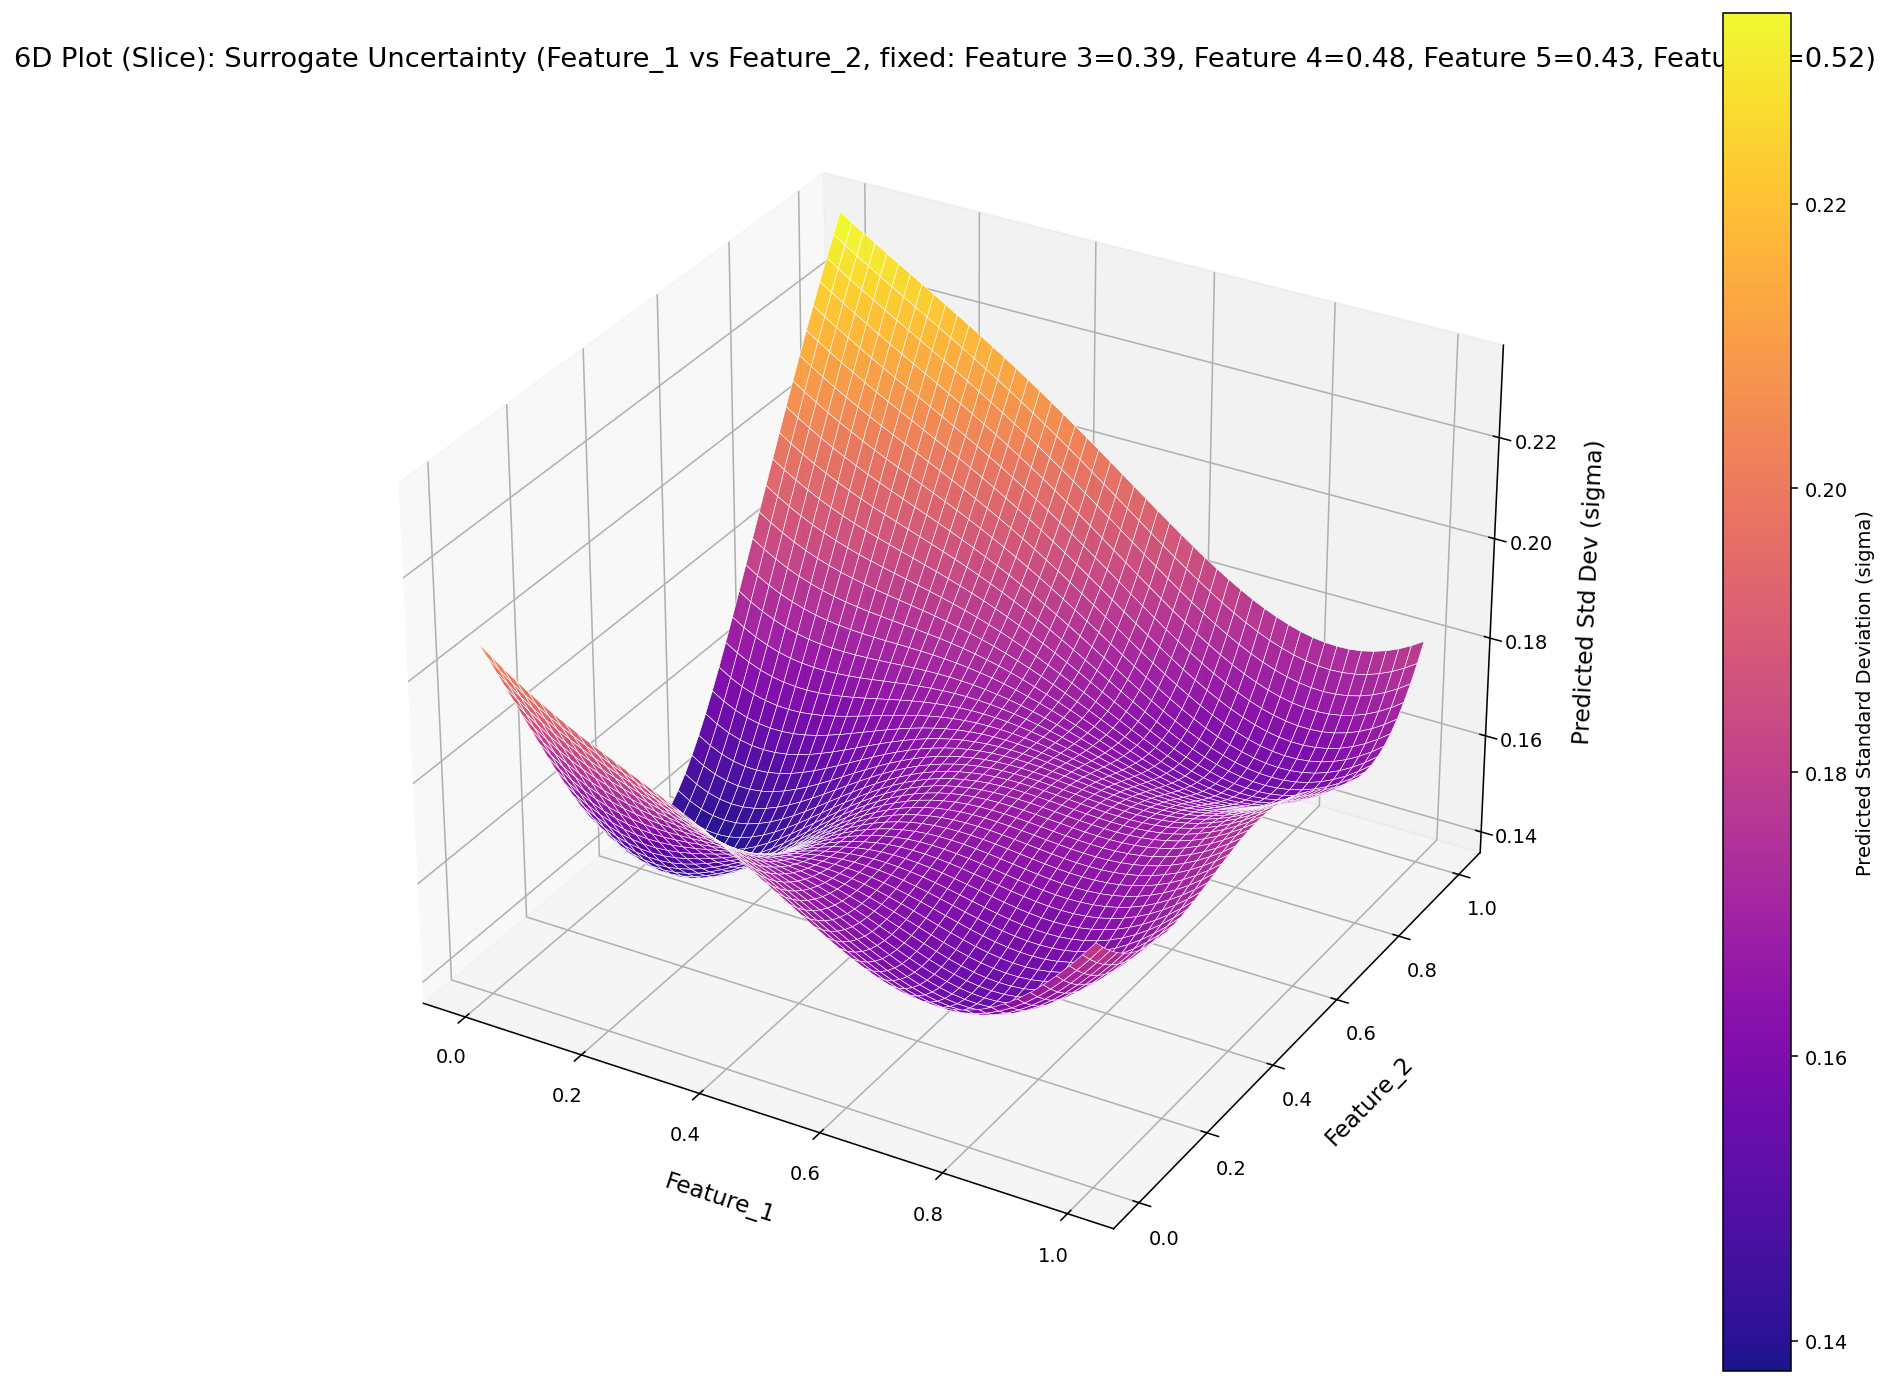

Displayed: 6D Slice Plot for Surrogate Uncertainty (Feature_1 vs Feature_2, fixed: Feature 3=0.39, Feature 4=0.48, Feature 5=0.43, Feature 6=0.52)


In [24]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.cm as cm

def plot_2d_slice(gp, X_obs, y_obs, f1_idx, f2_idx, f1_name, f2_name, resolution=50, tolerance=0.1):
    """
    Generates 3D slice plots (mean and uncertainty) for a 6D Gaussian Process Regressor,
    varying two specified features and fixing the rest at their mean observed values.

    Args:
        gp (GaussianProcessRegressor): Fitted Gaussian Process Regressor model.
        X_obs (np.ndarray): Observed input data (6D array).
        y_obs (np.ndarray): Observed output data (1D array).
        f1_idx (int): Index of the first feature to vary (e.g., 0 for Feature 1).
        f2_idx (int): Index of the second feature to vary (e.g., 1 for Feature 2).
        f1_name (str): Name of the first feature.
        f2_name (str): Name of the second feature.
        resolution (int): Number of points to use for the grid along each varying dimension.
        tolerance (float): Tolerance for selecting observed points close to fixed feature means.
    """
    num_features = X_obs.shape[1]
    mean_X_obs = np.mean(X_obs, axis=0)

    # Create a 2D grid for the two features we will vary
    x1_grid = np.linspace(0, 1, resolution)
    x2_grid = np.linspace(0, 1, resolution)
    X1, X2 = np.meshgrid(x1_grid, x2_grid)

    # Construct the 6D input grid for prediction for this slice
    X_slice_grid_list = []
    fixed_feature_names_and_values = []
    for i in range(num_features):
        if i == f1_idx:
            X_slice_grid_list.append(X1.ravel())
        elif i == f2_idx:
            X_slice_grid_list.append(X2.ravel())
        else:
            # Fix other features at their mean values
            X_slice_grid_list.append(np.full(X1.size, mean_X_obs[i]))
            fixed_feature_names_and_values.append(f"Feature {i+1}={mean_X_obs[i]:.2f}")

    X_slice_grid = np.column_stack(X_slice_grid_list)
    fixed_features_str = ", ".join(fixed_feature_names_and_values)

    # Predict mean and std for this slice from the GPR
    mu_slice, std_slice = gp.predict(X_slice_grid, return_std=True)
    Mu_slice_surface = mu_slice.reshape(resolution, resolution)
    Std_slice_surface = std_slice.reshape(resolution, resolution)

    # ───────────────────────────────
    # Plot the surrogate mean surface
    # ───────────────────────────────
    fig_mean = plt.figure(figsize=(12, 10))
    ax_mean = fig_mean.add_subplot(111, projection='3d')

    surf_mean = ax_mean.plot_surface(
        X1, X2, Mu_slice_surface,
        cmap='viridis',
        edgecolor='white',
        linewidth=0.3,
        alpha=0.95
    )

    # Scatter the observed points where fixed features are close to their mean values
    close_points_mask = np.ones(len(X_obs), dtype=bool)
    for idx in range(num_features):
        if idx != f1_idx and idx != f2_idx:
            mask_dim = (X_obs[:, idx] >= mean_X_obs[idx] - tolerance) & \
                       (X_obs[:, idx] <= mean_X_obs[idx] + tolerance)
            close_points_mask = close_points_mask & mask_dim

    if np.any(close_points_mask):
        ax_mean.scatter(
            X_obs[close_points_mask, f1_idx], X_obs[close_points_mask, f2_idx], y_obs[close_points_mask],
            color='red', s=50, zorder=5, label='Observations near fixed means', alpha=0.9
        )

    fig_mean.colorbar(surf_mean, ax=ax_mean, pad=0.1).set_label('Predicted Mean Target (mu)')
    ax_mean.set_title(f'6D Plot (Slice): Surrogate Mean ({f1_name} vs {f2_name}, fixed: {fixed_features_str})', fontsize=14)
    ax_mean.set_xlabel(f1_name, fontsize=12, labelpad=10)
    ax_mean.set_ylabel(f2_name, fontsize=12, labelpad=10)
    ax_mean.set_zlabel('Predicted Mean (mu)', fontsize=12, labelpad=10)
    ax_mean.tick_params(axis='both', labelsize=10)
    if np.any(close_points_mask): ax_mean.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'surrogate_mean_slice_{f1_name.replace(" ", "_")}_{f2_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Displayed: 6D Slice Plot for Surrogate Mean ({f1_name} vs {f2_name}, fixed: {fixed_features_str})")

    # ───────────────────────────────
    # Plot the surrogate uncertainty surface
    # ───────────────────────────────
    fig_std = plt.figure(figsize=(12, 10))
    ax_std = fig_std.add_subplot(111, projection='3d')

    surf_std = ax_std.plot_surface(
        X1, X2, Std_slice_surface,
        cmap='plasma', # Good for uncertainty
        edgecolor='white',
        linewidth=0.3,
        alpha=0.95
    )

    # Scatter observed points on the uncertainty plot (projected to Z=0 for context)
    if np.any(close_points_mask):
        ax_std.scatter(
            X_obs[close_points_mask, f1_idx], X_obs[close_points_mask, f2_idx], np.zeros_like(y_obs[close_points_mask]),
            color='red', s=50, zorder=5, label='Observations near fixed means', alpha=0.9
        )

    fig_std.colorbar(surf_std, ax=ax_std, pad=0.1).set_label('Predicted Standard Deviation (sigma)')
    ax_std.set_title(f'6D Plot (Slice): Surrogate Uncertainty ({f1_name} vs {f2_name}, fixed: {fixed_features_str})', fontsize=14)
    ax_std.set_xlabel(f1_name, fontsize=12, labelpad=10)
    ax_std.set_ylabel(f2_name, fontsize=12, labelpad=10)
    ax_std.set_zlabel('Predicted Std Dev (sigma)', fontsize=12, labelpad=10)
    ax_std.tick_params(axis='both', labelsize=10)
    if np.any(close_points_mask): ax_std.legend(loc='upper left', fontsize=10)
    plt.tight_layout()
    plt.savefig(f'surrogate_uncertainty_slice_{f1_name.replace(" ", "_")}_{f2_name.replace(" ", "_")}.png', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Displayed: 6D Slice Plot for Surrogate Uncertainty ({f1_name} vs {f2_name}, fixed: {fixed_features_str})")

# Call the function for Feature 1 (index 0) and Feature 2 (index 1)
# `gpr_3d`, `X`, `y`, `resolution` are already available from previous cells.
feature_names_list = [f'Feature_{i+1}' for i in range(X.shape[1])]
plot_2d_slice(gpr_3d, X, y, f1_idx=0, f2_idx=1, f1_name=feature_names_list[0], f2_name=feature_names_list[1], resolution=resolution)


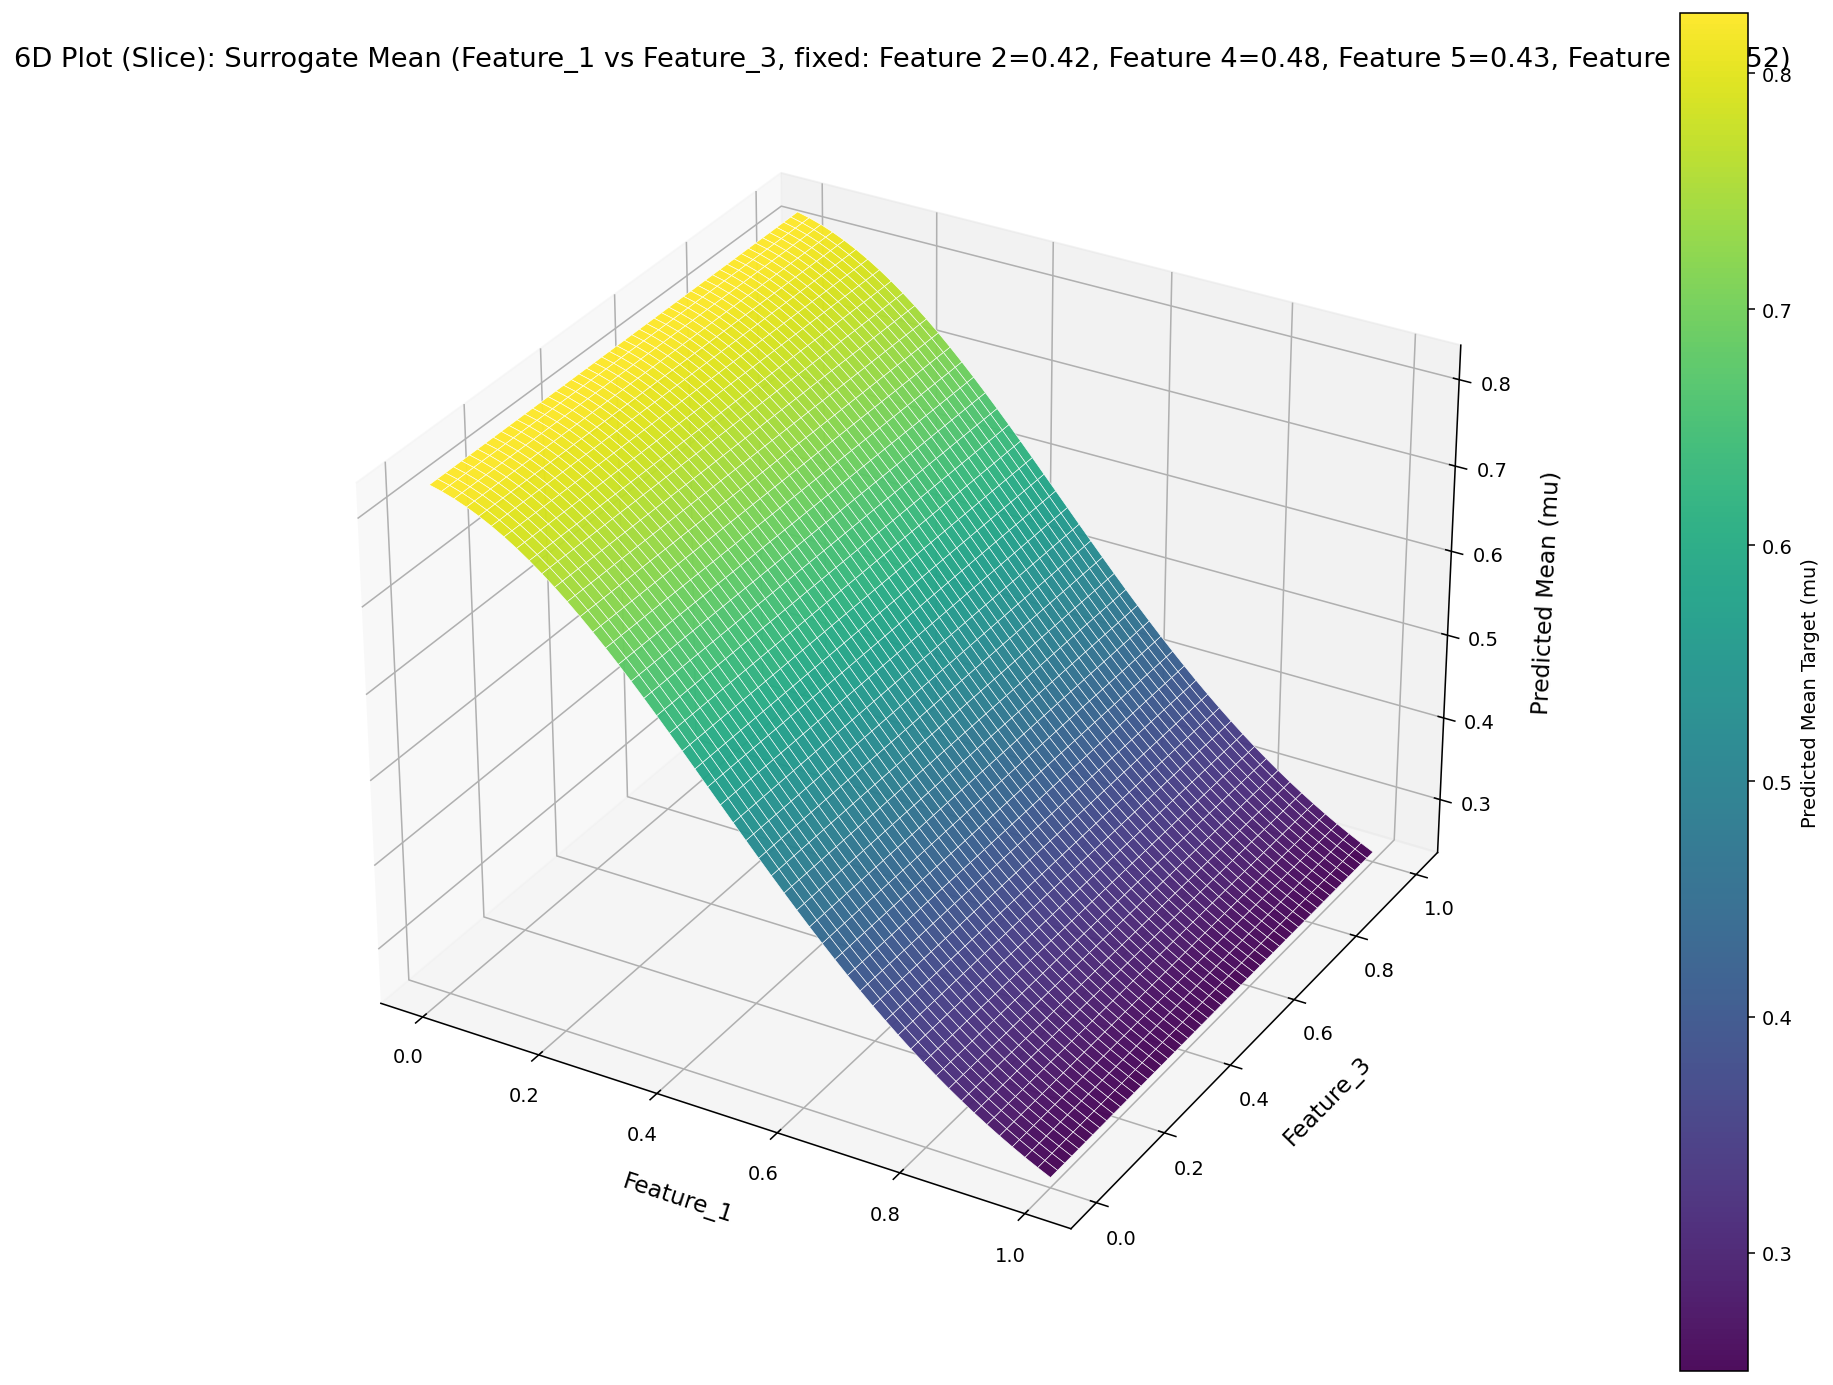

Displayed: 6D Slice Plot for Surrogate Mean (Feature_1 vs Feature_3, fixed: Feature 2=0.42, Feature 4=0.48, Feature 5=0.43, Feature 6=0.52)


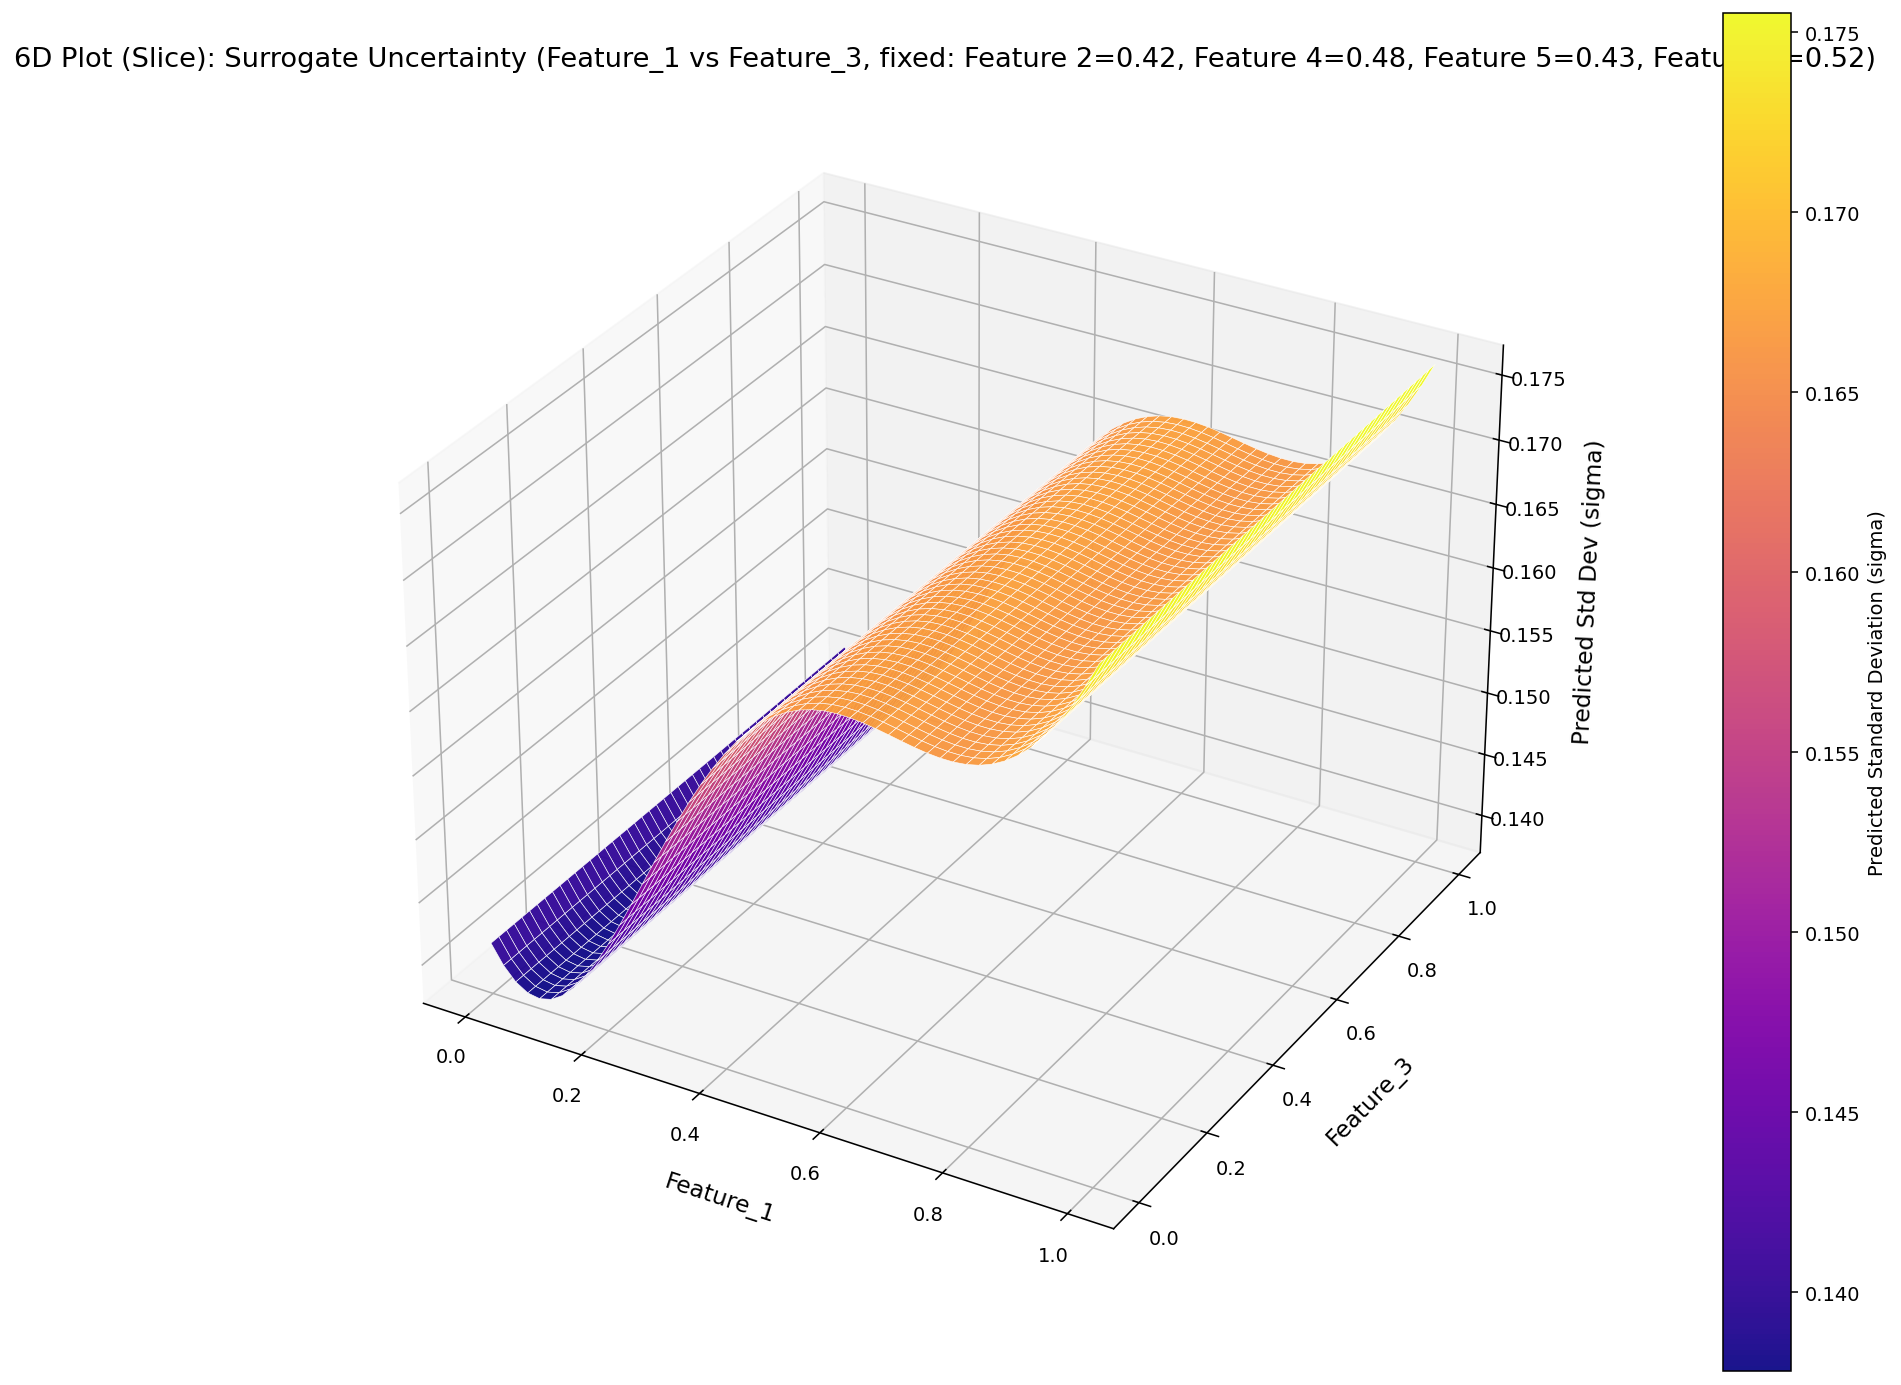

Displayed: 6D Slice Plot for Surrogate Uncertainty (Feature_1 vs Feature_3, fixed: Feature 2=0.42, Feature 4=0.48, Feature 5=0.43, Feature 6=0.52)


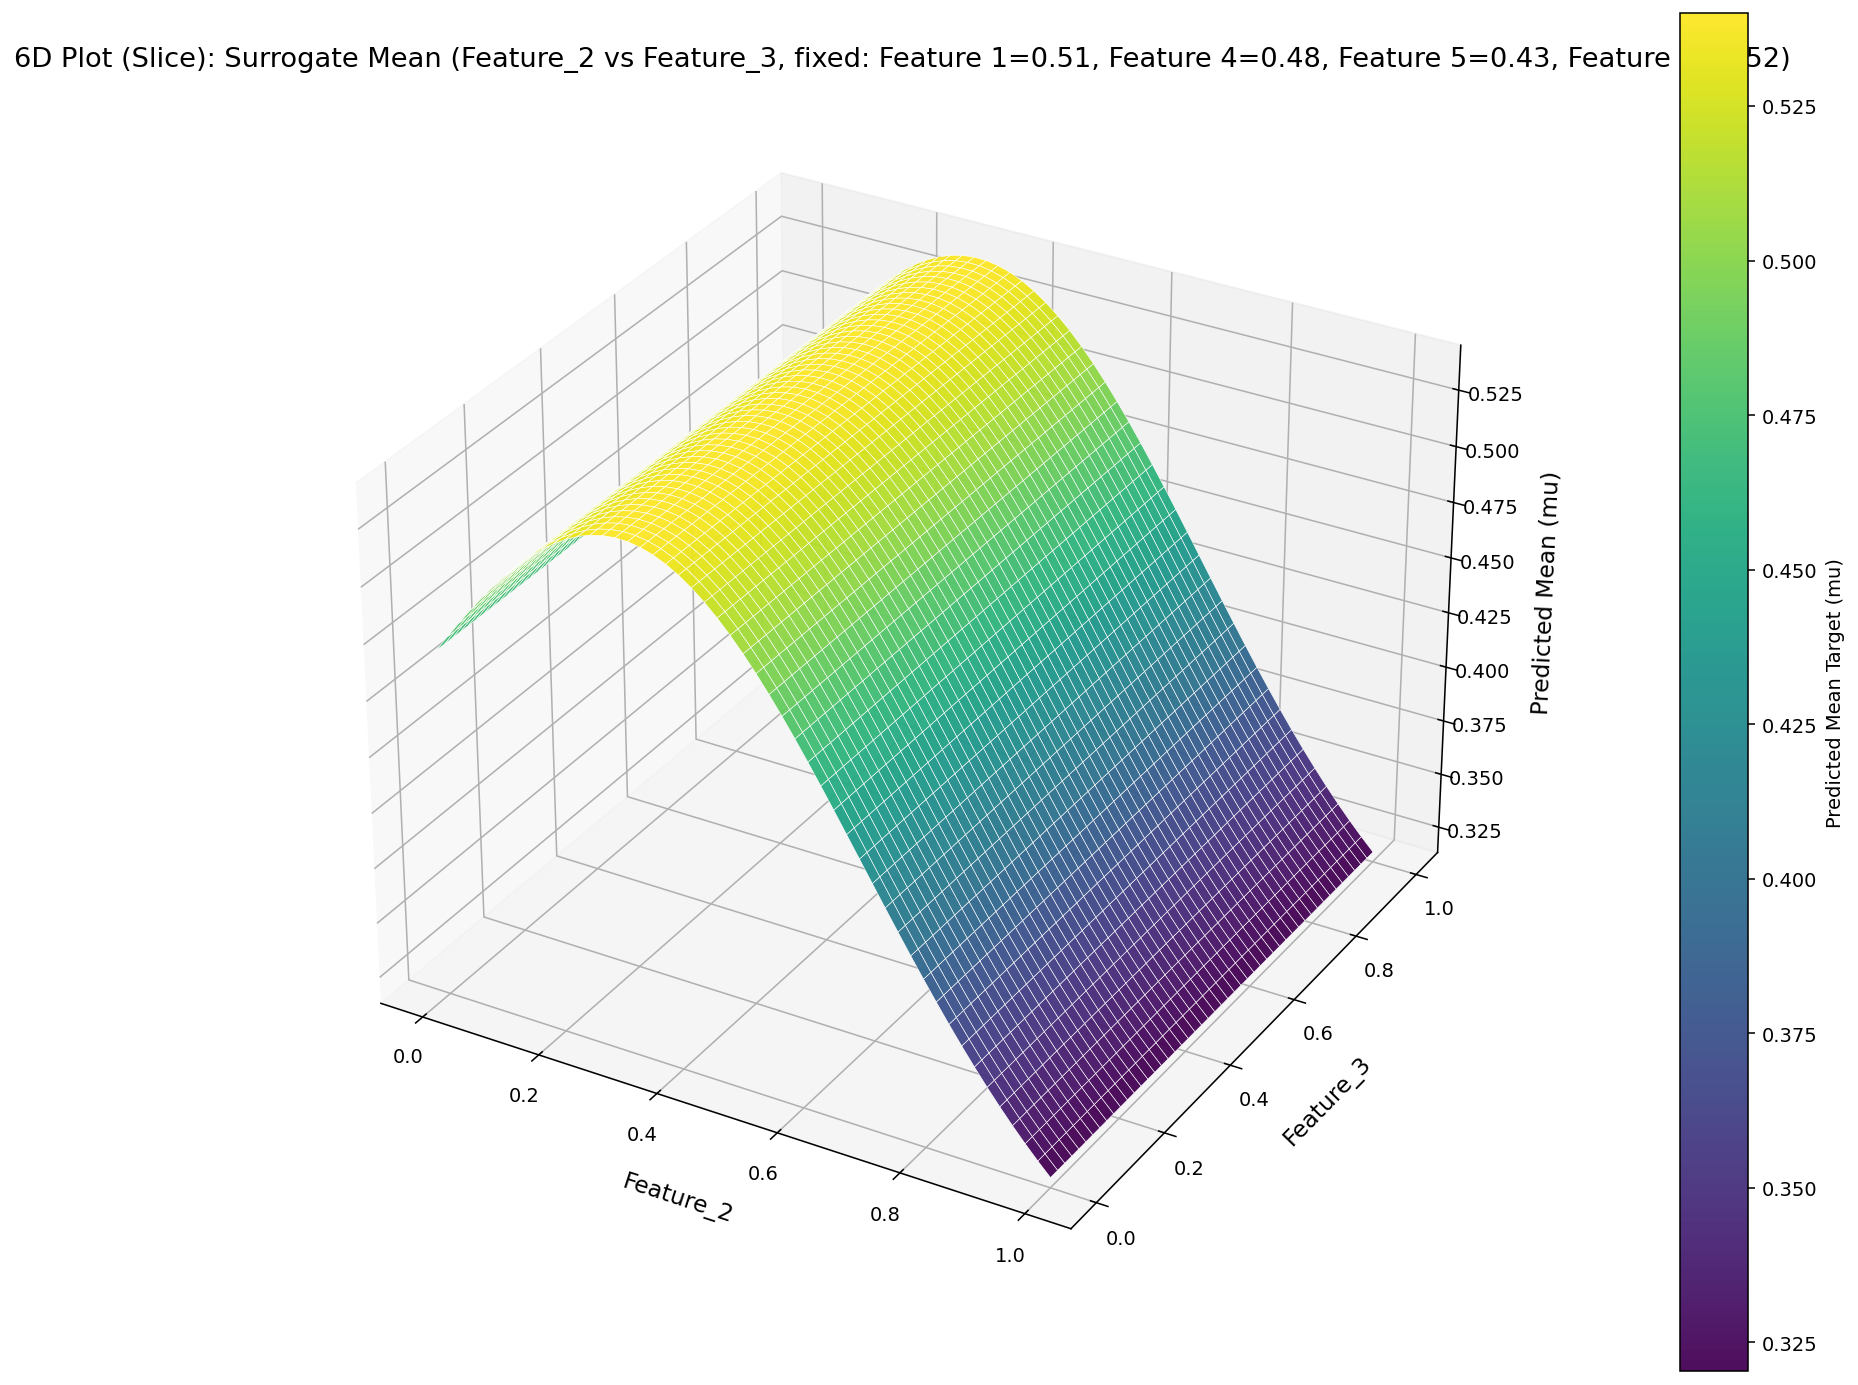

Displayed: 6D Slice Plot for Surrogate Mean (Feature_2 vs Feature_3, fixed: Feature 1=0.51, Feature 4=0.48, Feature 5=0.43, Feature 6=0.52)


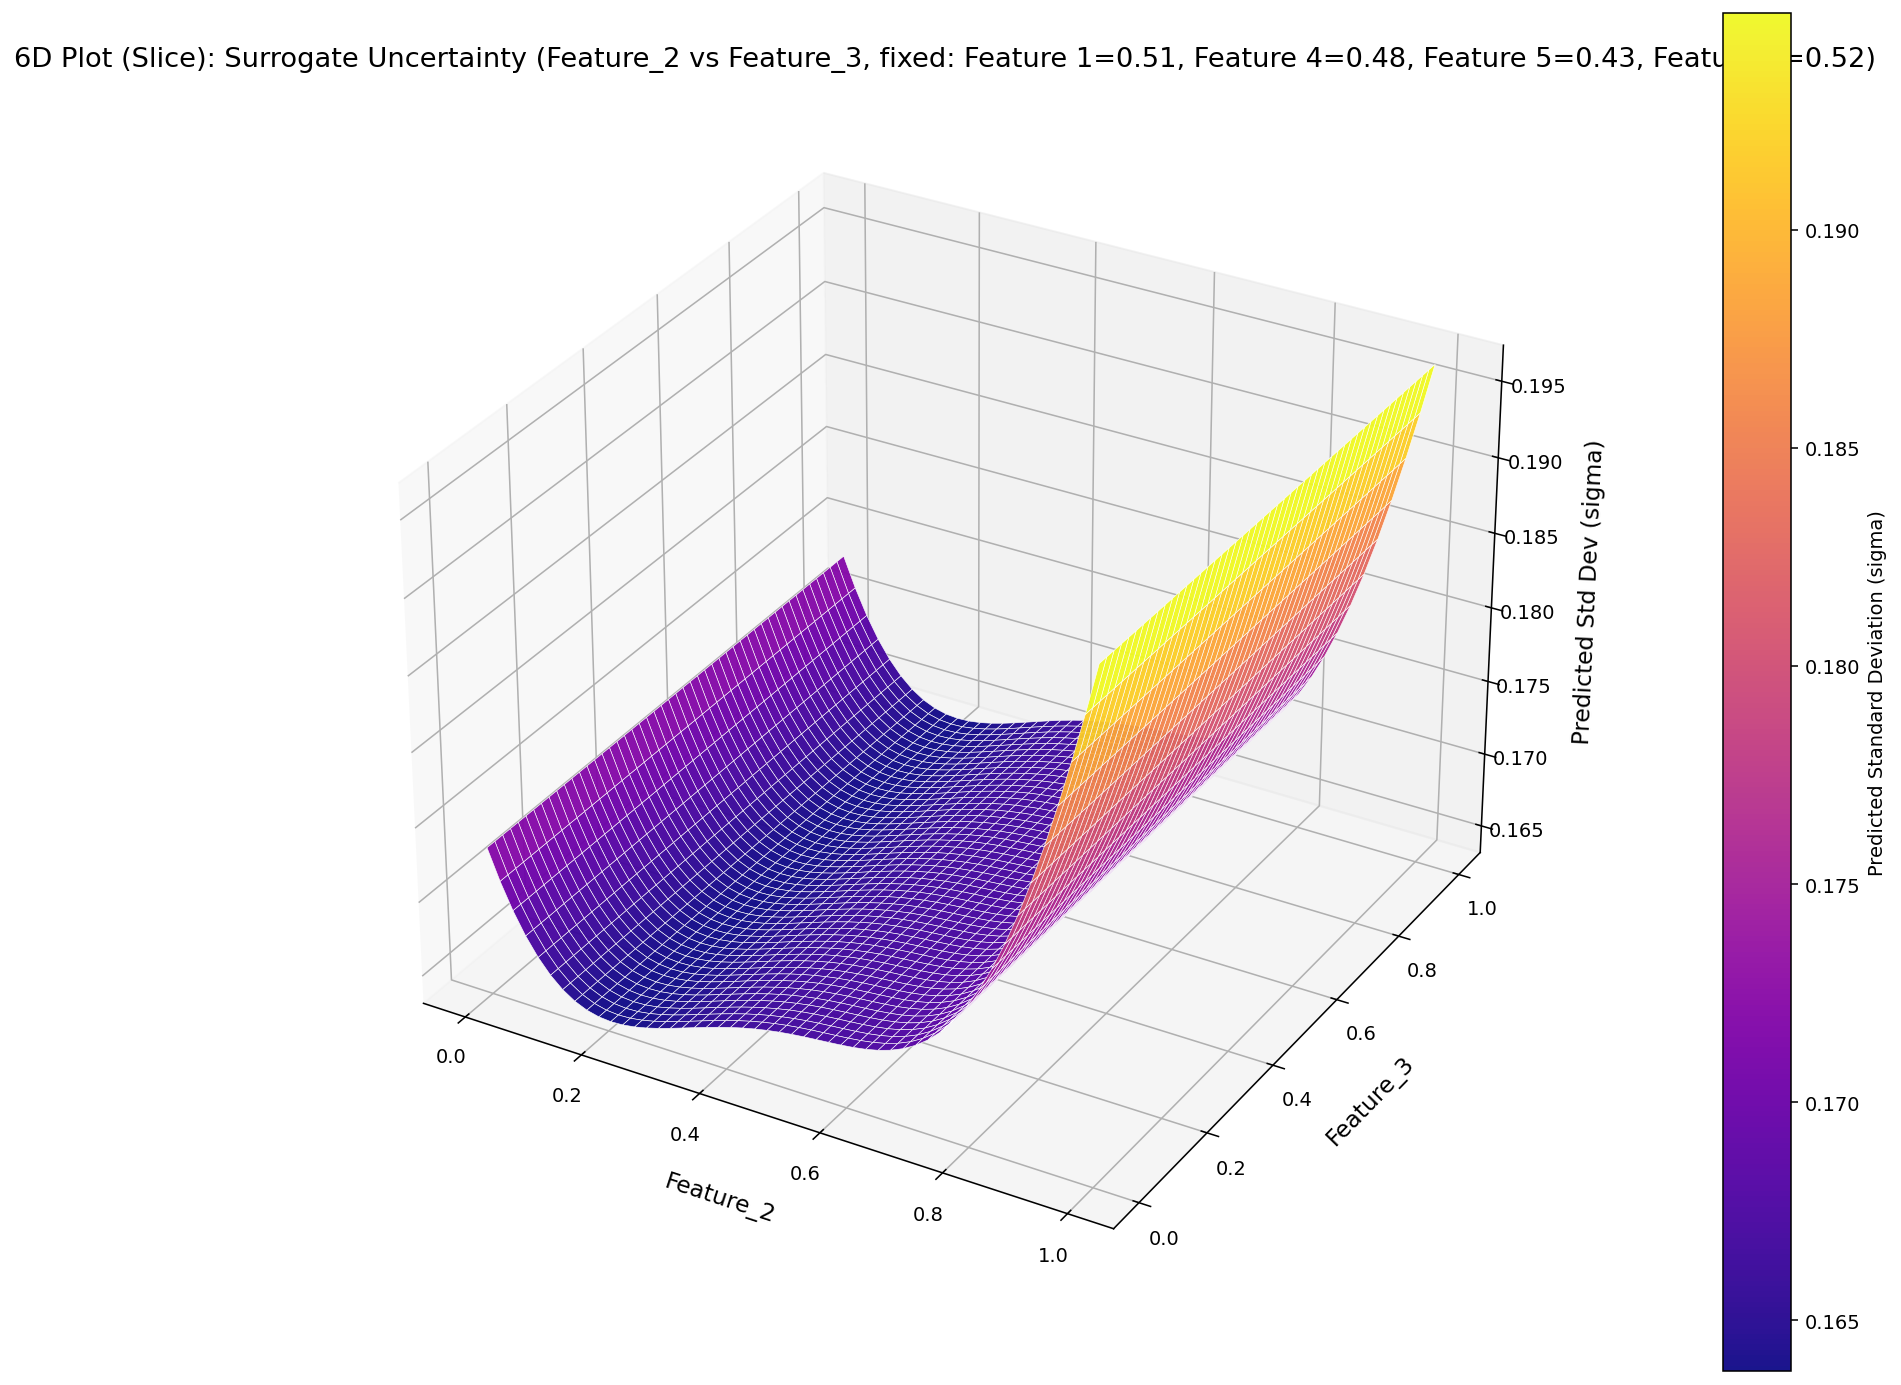

Displayed: 6D Slice Plot for Surrogate Uncertainty (Feature_2 vs Feature_3, fixed: Feature 1=0.51, Feature 4=0.48, Feature 5=0.43, Feature 6=0.52)


In [25]:
feature_names_list = [f'Feature_{i+1}' for i in range(X.shape[1])]

# Generate slice plots for Feature 1 (index 0) vs Feature 3 (index 2)
plot_2d_slice(gpr_3d, X, y, f1_idx=0, f2_idx=2, f1_name=feature_names_list[0], f2_name=feature_names_list[2], resolution=resolution)

# Generate slice plots for Feature 2 (index 1) vs Feature 3 (index 2)
plot_2d_slice(gpr_3d, X, y, f1_idx=1, f2_idx=2, f1_name=feature_names_list[1], f2_name=feature_names_list[2], resolution=resolution)

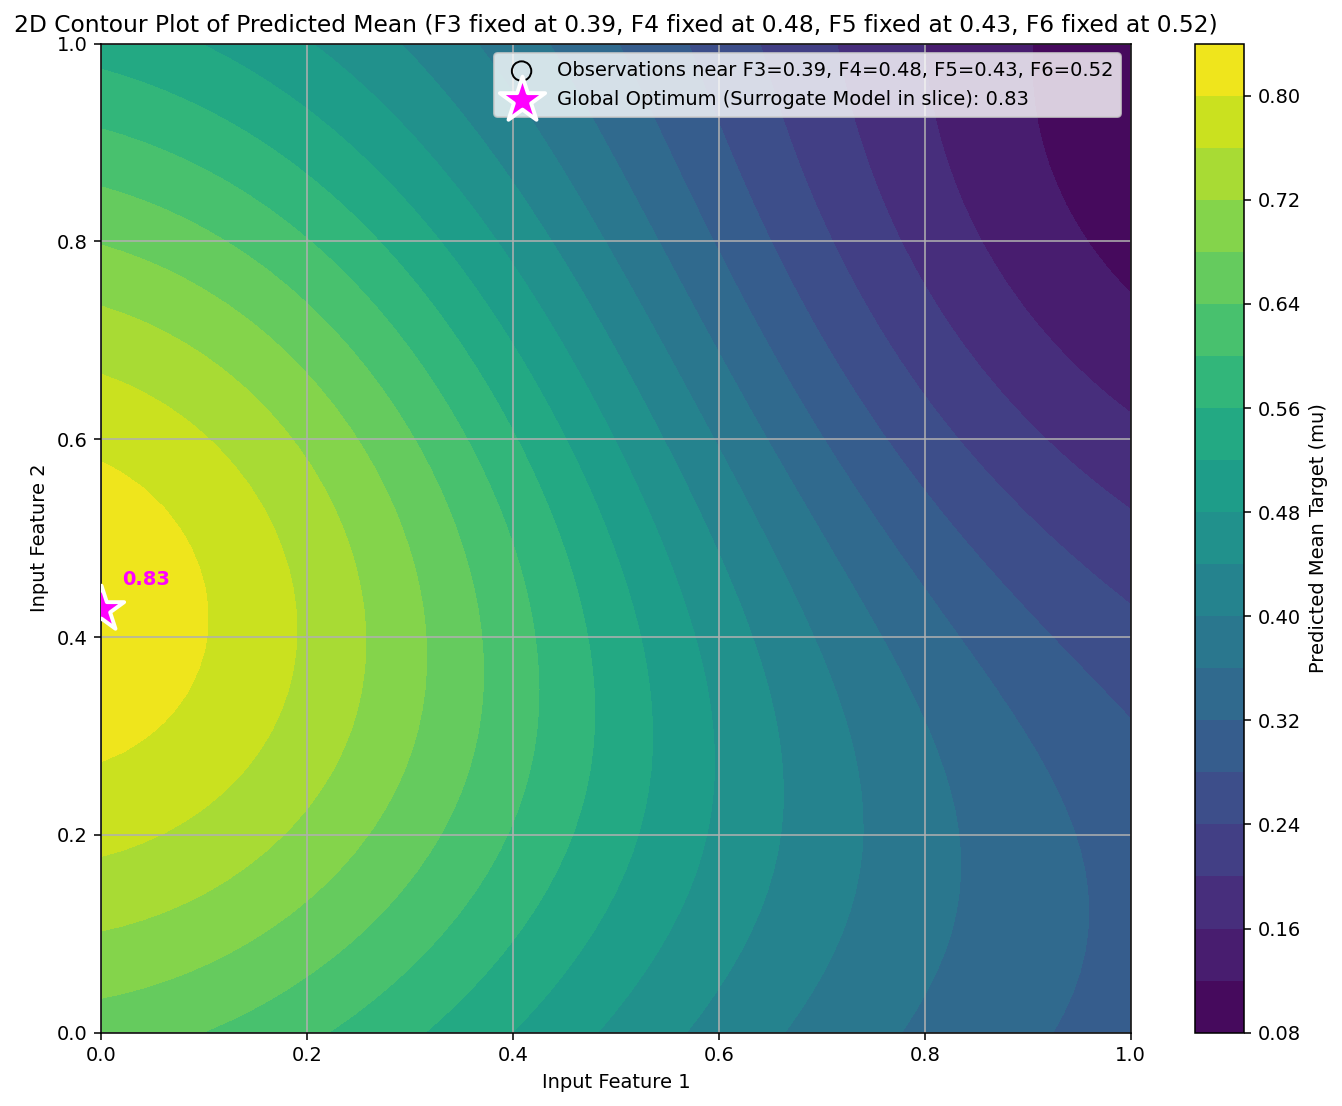

Saved: gp_surrogate_mean_contour_6d_input_slice.png

Global Optimum within slice (X1, X2, fixed X3, fixed X4, fixed X5, fixed X6): [0.         0.42857143 0.38646874 0.47519057 0.42931613 0.52220185]
Predicted Mean Target (yield) at this point: 8.27547e-01


In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Assuming gpr_3d, X, y, next_x_data_point, predicted_y_at_next_x are available from previous cells.

# Define parameters for the 2D slice visualization (fixing Features 3, 4, 5 and 6)
# Using mean values of observed data for fixed features, similar to the 5D slice plots in the previous cell
fixed_x3_value = np.mean(X[:, 2])
fixed_x4_value = np.mean(X[:, 3])
fixed_x5_value = np.mean(X[:, 4])
fixed_x6_value = np.mean(X[:, 5]) # Added fixed_x6_value

resolution = 50 # Resolution for the grid of the 2D slice

# Create a grid for X[:,0] and X[:,1]
x1_grid = np.linspace(0, 1, resolution)
x2_grid = np.linspace(0, 1, resolution)
X1, X2 = np.meshgrid(x1_grid, x2_grid)

# Create the 6D input grid for prediction for this slice
# Each point will be [X1_val, X2_val, fixed_x3_value, fixed_x4_value, fixed_x5_value, fixed_x6_value]
X_slice_grid = np.column_stack([X1.ravel(), X2.ravel(),
                                np.full(X1.size, fixed_x3_value),
                                np.full(X1.size, fixed_x4_value),
                                np.full(X1.size, fixed_x5_value),
                                np.full(X1.size, fixed_x6_value)]) # Updated to include fixed_x6_value

# Predict mean from the fitted GPR (gpr_3d)
mu_slice, _ = gpr_3d.predict(X_slice_grid, return_std=True)
Mu_slice_surface = mu_slice.reshape(resolution, resolution)

fig, ax = plt.subplots(figsize=(10, 8)) # Get fig and ax objects
contour = ax.contourf(X1, X2, Mu_slice_surface, levels=20, cmap='viridis')
fig.colorbar(contour, ax=ax, label='Predicted Mean Target (mu)')

# Scatter the observed points that are close to the fixed feature values
tolerance = 0.1 # Define a tolerance for "close"
close_points_mask = ((X[:, 2] >= fixed_x3_value - tolerance) & (X[:, 2] <= fixed_x3_value + tolerance)) & \
                    ((X[:, 3] >= fixed_x4_value - tolerance) & (X[:, 3] <= fixed_x4_value + tolerance)) & \
                    ((X[:, 4] >= fixed_x5_value - tolerance) & (X[:, 4] <= fixed_x5_value + tolerance)) & \
                    ((X[:, 5] >= fixed_x6_value - tolerance) & (X[:, 5] <= fixed_x6_value + tolerance)) # Updated mask
ax.scatter(
    X[close_points_mask, 0], X[close_points_mask, 1], c=y[close_points_mask],
    cmap='viridis', s=100, edgecolors='k', label=f'Observations near F3={fixed_x3_value:.2f}, F4={fixed_x4_value:.2f}, F5={fixed_x5_value:.2f}, F6={fixed_x6_value:.2f}' # Updated label
)

# Mark the suggested next sample point (if it falls within this slice)
# Check all fixed features for proximity
if np.isclose(next_x_data_point[2], fixed_x3_value, atol=tolerance) and \
   np.isclose(next_x_data_point[3], fixed_x4_value, atol=tolerance) and \
   np.isclose(next_x_data_point[4], fixed_x5_value, atol=tolerance) and \
   np.isclose(next_x_data_point[5], fixed_x6_value, atol=tolerance): # Updated proximity check
    ax.scatter(next_x_data_point[0], next_x_data_point[1],
                color='red', marker='X', s=200, label='Suggested Next Sample Point', zorder=5)

# Find the global maximum of Mu_slice_surface (as we are maximizing the transformed output)
# This is the global optimum *within this specific 2D slice* (for the two varying features)
max_mu_slice_idx = np.argmax(Mu_slice_surface)
# Get the 6D coordinates of this point within the slice
max_mu_slice_coords_flattened = X_slice_grid[max_mu_slice_idx] # X_slice_grid is now 6D
max_mu_value_in_slice = Mu_slice_surface.max()

ax.scatter(
    max_mu_slice_coords_flattened[0], max_mu_slice_coords_flattened[1],
    color='magenta', marker='*', s=600, zorder=10, edgecolor='white', linewidth=2,
    label=f'Global Optimum (Surrogate Model in slice): {max_mu_value_in_slice:.2f}'
)

# Add text annotation for clarity
ax.text(max_mu_slice_coords_flattened[0] + 0.02, max_mu_slice_coords_flattened[1] + 0.02,
         f'{max_mu_value_in_slice:.2f}', color='magenta', fontsize=10, ha='left', va='bottom', weight='bold')

ax.set_title(f'2D Contour Plot of Predicted Mean (F3 fixed at {fixed_x3_value:.2f}, F4 fixed at {fixed_x4_value:.2f}, F5 fixed at {fixed_x5_value:.2f}, F6 fixed at {fixed_x6_value:.2f})') # Updated title
ax.set_xlabel('Input Feature 1')
ax.set_ylabel('Input Feature 2')
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.savefig('gp_surrogate_mean_contour_6d_input_slice.png', dpi=150, bbox_inches='tight') # Updated filename
plt.show()
print("Saved: gp_surrogate_mean_contour_6d_input_slice.png") # Updated filename
print(f"\nGlobal Optimum within slice (X1, X2, fixed X3, fixed X4, fixed X5, fixed X6): {max_mu_slice_coords_flattened}") # Updated print statement
print(f"Predicted Mean Target (yield) at this point: {max_mu_value_in_slice:.5e}")

In [27]:
# --- 1. Global Maximum identified from Observed Data (y) ---
max_y_observed = np.max(y)
max_y_observed_idx = np.argmax(y)
max_X_observed = X[max_y_observed_idx]

print(f"\nObserved Global Maximum 'y' value: {max_y_observed:.5e}")
print(f"Corresponding 'X' values (Index {max_y_observed_idx}): {max_X_observed}")

# --- 2. Predicted Global Maximum (based on Surrogate Model gpr_3d) ---
# The gpr_3d model was already fitted in cell '4HScECjpuxOK' on X and y
# We will use the 'mu_3d' array which contains the predicted mean 'y' values for 'candidates_3d'

# Find the index of the maximum predicted mean 'y' value among all candidates
predicted_global_max_idx = np.argmax(mu_3d)
predicted_global_max_y = mu_3d[predicted_global_max_idx]
predicted_global_max_X = candidates_3d[predicted_global_max_idx]

# Get the uncertainty (standard deviation) at this predicted global maximum point
predicted_global_max_std = std_3d[predicted_global_max_idx]

print(f"\nPredicted Global Maximum 'y' value (from surrogate mean): {predicted_global_max_y:.5e}")
print(f"Corresponding 'X' values: {predicted_global_max_X}")
print(f"Uncertainty (std) at this predicted point: {predicted_global_max_std:.5e}")


Observed Global Maximum 'y' value: 1.36497e+00
Corresponding 'X' values (Index 6): [0.05789554 0.49167222 0.24742222 0.21811844 0.42042833 0.73096984]

Predicted Global Maximum 'y' value (from surrogate mean): 1.33686e+00
Corresponding 'X' values: [0.00497741 0.53686708 0.41111698 0.25181151 0.403786   0.71868694]
Uncertainty (std) at this predicted point: 5.26684e-02
